# **CODES**

## **Data Cleaning & Preprocessing**

In [ ]:
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Load raw files
# ----------------------------------------------------------
df1           = pd.read_csv('numberofpublicschool2016-2019.csv', header=None)
df2           = pd.read_csv('NumberofSchool2017-21.csv', header=None)
df_teachers   = pd.read_csv('NumberofTeachersSY2010-2021.csv', header=6)
df_enroll_raw = pd.read_csv('ph_school_enrollment.csv')

# ----------------------------------------------------------
# Region setup
# ----------------------------------------------------------
regions = [
    'Philippines', 'NCR', 'CAR', 'Ilocos Region', 'Cagayan Valley',
    'Central Luzon', 'CALABARZON', 'MIMAROPA', 'Bicol Region',
    'Western Visayas', 'Central Visayas', 'Eastern Visayas',
    'Zamboanga Peninsula', 'Northern Mindanao', 'Davao Region',
    'SOCCSKSARGEN', 'Caraga', 'BARMM'
]
region_cols = list(range(2, 20))
target_sy   = ['SY 2016-2017', 'SY 2017-2018', 'SY 2018-2019',
               'SY 2019-2020', 'SY 2020-2021']
sy_to_year  = {
    'SY 2016-2017': 2017, 'SY 2017-2018': 2018, 'SY 2018-2019': 2019,
    'SY 2019-2020': 2020, 'SY 2020-2021': 2021
}
region_map = {
    'Region I - Ilocos Region':                                    'Ilocos Region',
    'Region II - Cagayan Valley':                                  'Cagayan Valley',
    'Region III - Central Luzon':                                  'Central Luzon',
    'Region IV-A - CALABARZON':                                    'CALABARZON',
    'Region IV-B - MIMAROPA':                                      'MIMAROPA',
    'Region V - Bicol Region':                                     'Bicol Region',
    'Region VI - Western Visayas':                                 'Western Visayas',
    'Region VII - Central Visayas':                                'Central Visayas',
    'Region VIII - Eastern Visayas':                               'Eastern Visayas',
    'Region IX - Zamboanga Peninsula':                             'Zamboanga Peninsula',
    'Region X - Northern Mindanao':                                'Northern Mindanao',
    'Region XI - Davao Region':                                    'Davao Region',
    'Region XII - Soccsksargen':                                   'SOCCSKSARGEN',
    'CARAGA - CARAGA':                                             'Caraga',
    'BARMM - Bangsamoro Autonomous Region in Muslim Mindanao':     'BARMM',
    'CAR - Cordillera Administrative Region':                      'CAR',
    'NCR - National Capital Region':                               'NCR',
    'PHILIPPINES TOTAL':                                           'Philippines',
}

# ----------------------------------------------------------
# Build Schools DataFrame
# ----------------------------------------------------------
school_map = {
    'SY 2016-2017': (df1, 15), 'SY 2017-2018': (df1, 28),
    'SY 2018-2019': (df1, 41), 'SY 2019-2020': (df2, 26),
    'SY 2020-2021': (df2, 36),
}
schools = {}
for sy, (src, row) in school_map.items():
    raw = src.iloc[row, region_cols].values
    schools[sy] = pd.to_numeric([str(v).replace(',', '') for v in raw], errors='coerce')
df_schools = pd.DataFrame(schools, index=regions)

# ----------------------------------------------------------
# Build Teachers DataFrame
# ----------------------------------------------------------
df_teachers['Region'] = df_teachers['Region'].str.strip().map(region_map)
df_teachers = df_teachers.dropna(subset=['Region']).set_index('Region')[target_sy]
df_teachers = df_teachers.apply(
    lambda x: pd.to_numeric(x.astype(str).str.replace(',', ''), errors='coerce')
)
df_teachers = df_teachers.reindex(regions)

# ----------------------------------------------------------
# Build Enrollment DataFrame
# ----------------------------------------------------------
grades = ['Kindergarten', 'Grade 1', 'Grade 2', 'Grade 3',
          'Grade 4', 'Grade 5', 'Grade 6']
df_pub = df_enroll_raw[df_enroll_raw['sector'] == 'Public'].copy()
df_pub['Region_std'] = df_pub['Region'].str.strip().map(region_map)
df_pub['Enroll'] = df_pub[grades].apply(pd.to_numeric, errors='coerce').sum(axis=1)
df_enroll_pivot = df_pub.pivot_table(
    index='Region_std', columns='Academic_Year', values='Enroll', aggfunc='sum'
)[target_sy]
df_enroll_pivot.loc['Philippines'] = df_enroll_pivot.sum()
df_enroll_pivot = df_enroll_pivot.reindex(regions)
df_enroll_pivot.index.name = 'Region'

# ----------------------------------------------------------
# Build long-format dataset
# ----------------------------------------------------------
rows = []
for sy in target_sy:
    for region in regions:
        if region == 'Philippines':
            continue
        rows.append({
            'Region':      region,
            'School_Year': sy,
            'Year':        sy_to_year[sy],
            'Schools':     df_schools.loc[region, sy],
            'Enrollment':  df_enroll_pivot.loc[region, sy],
            'Teachers':    df_teachers.loc[region, sy],
        })
df_full = pd.DataFrame(rows).dropna()

# ----------------------------------------------------------
# Split BARMM out
# ----------------------------------------------------------
df_barmm = df_full[df_full['Region'] == 'BARMM'].copy().reset_index(drop=True)
df_model = df_full[df_full['Region'] != 'BARMM'].copy().reset_index(drop=True)

# ----------------------------------------------------------
# Feature Engineering
# ----------------------------------------------------------
year_mean = df_model['Year'].mean()

for df in [df_model, df_barmm]:
    df['Students_per_School'] = df['Enrollment'] / df['Schools']
    df['Year_c']              = df['Year'] - year_mean
    df['Year_squared']        = df['Year_c'] ** 2
    df['log_Teachers']        = np.log(df['Teachers'])
    df['log_Enrollment']      = np.log(df['Enrollment'])

# Save
df_model.to_csv('df_model_clean.csv', index=False)
df_barmm.to_csv('df_barmm_clean.csv', index=False)

print("Cell 1 complete — datasets saved:")
print(f"  df_model_clean.csv  ->  {df_model.shape[0]} rows, {df_model.shape[1]} columns")
print(f"  df_barmm_clean.csv  ->  {df_barmm.shape[0]} rows, {df_barmm.shape[1]} columns")
print(df_model.head())

Cell 1 complete — datasets saved:
  df_model_clean.csv  ->  80 rows, 11 columns
  df_barmm_clean.csv  ->  5 rows, 11 columns
           Region   School_Year  Year  Schools  Enrollment  Teachers  \
0             NCR  SY 2016-2017  2017      518     1305754     35993   
1             CAR  SY 2016-2017  2017     1531      231438      9838   
2   Ilocos Region  SY 2016-2017  2017     2406      681650     24237   
3  Cagayan Valley  SY 2016-2017  2017     2200      492695     18098   
4   Central Luzon  SY 2016-2017  2017     3003     1478061     43342   

   Students_per_School  Year_c  Year_squared  log_Teachers  log_Enrollment  
0          2520.760618    -2.0           4.0     10.491080       14.082291  
1           151.167864    -2.0           4.0      9.194008       12.352067  
2           283.312552    -2.0           4.0     10.095636       13.432272  
3           223.952273    -2.0           4.0      9.803557       13.107646  
4           492.194805    -2.0           4.0     10.67687

## **Multiple Linear Regression**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------
df_model = pd.read_csv('df_model_clean.csv')
df_barmm = pd.read_csv('df_barmm_clean.csv')

# ----------------------------------------------------------
# FEATURES & TARGET
# ----------------------------------------------------------
feature_cols   = ['log_Enrollment', 'Students_per_School', 'Year_c', 'Year_squared']
region_dummies = pd.get_dummies(df_model['Region'], drop_first=True)

X_raw = pd.concat([df_model[feature_cols], region_dummies], axis=1)
y     = df_model['log_Teachers']

num_cols   = feature_cols
dummy_cols = list(region_dummies.columns)

# ----------------------------------------------------------
# TRAIN-TEST SPLIT
# ----------------------------------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# SCALING — numeric features only, no leakage
# ----------------------------------------------------------
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_raw[num_cols])
X_test_num  = scaler.transform(X_test_raw[num_cols])

X_train = np.hstack([X_train_num, X_train_raw[dummy_cols].values])
X_test  = np.hstack([X_test_num,  X_test_raw[dummy_cols].values])

# ----------------------------------------------------------
# MODEL
# ----------------------------------------------------------
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# ----------------------------------------------------------
# PREDICTIONS — back-transform with np.exp()
# ----------------------------------------------------------
y_pred_train_log = mlr.predict(X_train)
y_pred_test_log  = mlr.predict(X_test)

y_train_real = np.exp(y_train)
y_test_real  = np.exp(y_test)

y_pred_train = np.exp(y_pred_train_log)
y_pred_test  = np.exp(y_pred_test_log)

# ----------------------------------------------------------
# CROSS-VALIDATION — computed once here
# ----------------------------------------------------------
cv_scores = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2')

# ----------------------------------------------------------
# EVALUATION METRICS
# ----------------------------------------------------------
r2_train = r2_score(y_train_real, y_pred_train)
r2_test  = r2_score(y_test_real,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
mae      = mean_absolute_error(y_test_real, y_pred_test)

print("================ BASIC MLR RESULTS ================")
print(f"R² Train      : {r2_train:.4f}")
print(f"R² Test       : {r2_test:.4f}")
print(f"RMSE          : {rmse:,.2f}")
print(f"MAE           : {mae:,.2f}")
print(f"CV R² Scores  : {np.round(cv_scores, 4)}")
print(f"Mean CV R²    : {cv_scores.mean():.4f}")
print(f"Std CV R²     : {cv_scores.std():.4f}")

# ----------------------------------------------------------
# COEFFICIENTS
# ----------------------------------------------------------
feature_names = num_cols + dummy_cols
coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': mlr.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n================ TOP COEFFICIENTS ================")
print(coef_df.head(10))
print(f"\nIntercept: {mlr.intercept_:.4f}")

# ----------------------------------------------------------
# VISUALIZATION 1 — Actual vs Predicted
# ----------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test_real, y_pred_test, alpha=0.7)
mn = min(y_test_real.min(), y_pred_test.min())
mx = max(y_test_real.max(), y_pred_test.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Actual Teachers")
plt.ylabel("Predicted Teachers")
plt.title(f"Basic MLR: Actual vs Predicted (R² = {r2_test:.4f})")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 2 — Residual Plot
# ----------------------------------------------------------
residuals = y_test_real - y_pred_test

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_test, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Teachers")
plt.ylabel("Residuals")
plt.title("Residual Plot (MLR Assumption Check)")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 3 — Residual Distribution
# ----------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, edgecolor='black')
plt.title("Residual Distribution (MLR)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 4 — Top Coefficients
# ----------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'][:10], coef_df['Coefficient'][:10])
plt.gca().invert_yaxis()
plt.title("Top MLR Coefficients")
plt.xlabel("Coefficient Value")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 5 — CV Scores Line Chart
# ----------------------------------------------------------
plt.figure(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]

plt.plot(folds, cv_scores, marker='o', color='steelblue',
         linewidth=2, markersize=8, label='CV R² per Fold')

for i, score in enumerate(cv_scores):
    plt.text(i, score + 0.0005, f'{score:.4f}', ha='center', va='bottom', fontsize=10)

plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean R² = {cv_scores.mean():.4f}')

plt.ylim(cv_scores.min() - 0.01, 1.01)
plt.ylabel("R² Score")
plt.title("5-Fold Cross-Validation R² — Basic MLR")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# BARMM OUT-OF-SAMPLE PREDICTION
# ----------------------------------------------------------
X_barmm_num = scaler.transform(df_barmm[num_cols])

barmm_dummies = pd.DataFrame(
    np.zeros((len(df_barmm), len(dummy_cols))),
    columns=dummy_cols
)

X_barmm = np.hstack([X_barmm_num, barmm_dummies.values])

barmm_pred_log = mlr.predict(X_barmm)
df_barmm['Predicted_Teachers'] = np.exp(barmm_pred_log)

# ----------------------------------------------------------
# VISUALIZATION 6 — BARMM Bar Chart
# ----------------------------------------------------------
plt.figure(figsize=(8, 4))
x = np.arange(len(df_barmm))
plt.bar(x - 0.2, df_barmm['Teachers'],           0.4, label='Actual')
plt.bar(x + 0.2, df_barmm['Predicted_Teachers'], 0.4, label='Predicted')
plt.xticks(x, df_barmm['School_Year'], rotation=30)
plt.title("BARMM: Actual vs Predicted Teachers (Basic MLR)")
plt.ylabel("Teachers")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# BARMM ERROR ANALYSIS
# ----------------------------------------------------------
df_barmm['Error']   = df_barmm['Teachers'] - df_barmm['Predicted_Teachers']
df_barmm['Error_%'] = (abs(df_barmm['Error']) / df_barmm['Teachers']) * 100

print("\n=== BARMM OUT-OF-SAMPLE RESULTS ===")
print(df_barmm[['School_Year', 'Teachers', 'Predicted_Teachers', 'Error_%']])
print(f"\nAverage BARMM Error: {df_barmm['Error_%'].mean():.1f}%")

## **Decision Tree Regression**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------
df_model = pd.read_csv('df_model_clean.csv')

# ----------------------------------------------------------
# FEATURES & TARGET — same as MLR
# ----------------------------------------------------------
feature_cols   = ['log_Enrollment', 'Students_per_School', 'Year_c', 'Year_squared']
region_dummies = pd.get_dummies(df_model['Region'], drop_first=True)

X_raw = pd.concat([df_model[feature_cols], region_dummies], axis=1)
y     = df_model['log_Teachers']

num_cols   = feature_cols
dummy_cols = list(region_dummies.columns)

# ----------------------------------------------------------
# TRAIN-TEST SPLIT — same seed as MLR
# ----------------------------------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# SCALING — same as MLR
# ----------------------------------------------------------
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_raw[num_cols])
X_test_num  = scaler.transform(X_test_raw[num_cols])

X_train = np.hstack([X_train_num, X_train_raw[dummy_cols].values])
X_test  = np.hstack([X_test_num,  X_test_raw[dummy_cols].values])

# ----------------------------------------------------------
# GRID SEARCH — find best hyperparameters to prevent overfitting
# ----------------------------------------------------------
param_grid = {
    'max_depth':        [2, 3, 4],
    'min_samples_split': [4, 6, 8, 10],
    'min_samples_leaf':  [2, 3, 4, 5],
    'max_features':      [0.5, 0.7, 1.0]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best Parameters Found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# ----------------------------------------------------------
# FINAL MODEL with best parameters
# ----------------------------------------------------------
dt = DecisionTreeRegressor(
    random_state=42,
    **best_params
)
dt.fit(X_train, y_train)

# ----------------------------------------------------------
# PREDICTIONS — back-transform with np.exp()
# ----------------------------------------------------------
y_pred_train_log = dt.predict(X_train)
y_pred_test_log  = dt.predict(X_test)

y_train_real = np.exp(y_train)
y_test_real  = np.exp(y_test)

y_pred_train = np.exp(y_pred_train_log)
y_pred_test  = np.exp(y_pred_test_log)

# ----------------------------------------------------------
# CROSS-VALIDATION with best parameters
# ----------------------------------------------------------
cv_scores = cross_val_score(
    DecisionTreeRegressor(random_state=42, **best_params),
    X_train, y_train, cv=5, scoring='r2'
)

# ----------------------------------------------------------
# EVALUATION METRICS
# ----------------------------------------------------------
r2_train = r2_score(y_train_real, y_pred_train)
r2_test  = r2_score(y_test_real,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
mae      = mean_absolute_error(y_test_real, y_pred_test)

print("\n================ DECISION TREE RESULTS (Tuned) ================")
print(f"R² Train      : {r2_train:.4f}")
print(f"R² Test       : {r2_test:.4f}")
print(f"Train-Test Gap: {abs(r2_train - r2_test):.4f}  (lower is better)")
print(f"RMSE          : {rmse:,.2f}")
print(f"MAE           : {mae:,.2f}")
print(f"CV R² Scores  : {np.round(cv_scores, 4)}")
print(f"Mean CV R²    : {cv_scores.mean():.4f}")
print(f"Std CV R²     : {cv_scores.std():.4f}")

# ----------------------------------------------------------
# VISUALIZATION — Decision Tree Plot
# ----------------------------------------------------------
feature_names = num_cols + dummy_cols

plt.figure(figsize=(24, 8))
plot_tree(
    dt,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,
    precision=3
)
plt.title(f"Decision Tree (Tuned — max_depth={best_params['max_depth']})", fontsize=16)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# BARMM OUT-OF-SAMPLE PREDICTION
# ----------------------------------------------------------
df_barmm = pd.read_csv('df_barmm_clean.csv')

X_barmm_num = scaler.transform(df_barmm[num_cols])

barmm_dummies = pd.DataFrame(
    np.zeros((len(df_barmm), len(dummy_cols))),
    columns=dummy_cols
)

X_barmm = np.hstack([X_barmm_num, barmm_dummies.values])

barmm_pred_log = dt.predict(X_barmm)
df_barmm['Predicted_Teachers'] = np.exp(barmm_pred_log)

# BARMM Bar Chart
plt.figure(figsize=(8, 4))
x = np.arange(len(df_barmm))
plt.bar(x - 0.2, df_barmm['Teachers'],           0.4, label='Actual',    color='steelblue')
plt.bar(x + 0.2, df_barmm['Predicted_Teachers'], 0.4, label='Predicted', color='darkorange')
plt.xticks(x, df_barmm['School_Year'], rotation=30)
plt.title("BARMM: Actual vs Predicted Teachers (Decision Tree Tuned)")
plt.ylabel("Teachers")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# BARMM Error
df_barmm['Error']   = df_barmm['Teachers'] - df_barmm['Predicted_Teachers']
df_barmm['Error_%'] = (abs(df_barmm['Error']) / df_barmm['Teachers']) * 100

print("\n=== BARMM OUT-OF-SAMPLE RESULTS (Decision Tree Tuned) ===")
print(df_barmm[['School_Year', 'Teachers', 'Predicted_Teachers', 'Error_%']])
print(f"\nAverage BARMM Error: {df_barmm['Error_%'].mean():.1f}%")

## **Random Forest**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------
df_model = pd.read_csv('df_model_clean.csv')
df_barmm = pd.read_csv('df_barmm_clean.csv')

# ----------------------------------------------------------
# FEATURES & TARGET — same as MLR and Decision Tree
# ----------------------------------------------------------
feature_cols   = ['log_Enrollment', 'Students_per_School', 'Year_c', 'Year_squared']
region_dummies = pd.get_dummies(df_model['Region'], drop_first=True)

X_raw = pd.concat([df_model[feature_cols], region_dummies], axis=1)
y     = df_model['log_Teachers']

num_cols   = feature_cols
dummy_cols = list(region_dummies.columns)

# ----------------------------------------------------------
# TRAIN-TEST SPLIT — same seed as MLR and Decision Tree
# ----------------------------------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# SCALING — same as MLR and Decision Tree
# ----------------------------------------------------------
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_raw[num_cols])
X_test_num  = scaler.transform(X_test_raw[num_cols])

X_train = np.hstack([X_train_num, X_train_raw[dummy_cols].values])
X_test  = np.hstack([X_test_num,  X_test_raw[dummy_cols].values])

# ----------------------------------------------------------
# GRID SEARCH — find best hyperparameters
# ----------------------------------------------------------
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 4, 5, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf':  [1, 2, 3],
    'max_features':      ['sqrt', 'log2', 1.0]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best Parameters Found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# ----------------------------------------------------------
# FINAL MODEL with best parameters
# ----------------------------------------------------------
rf = RandomForestRegressor(
    random_state=42,
    **best_params
)
rf.fit(X_train, y_train)

# ----------------------------------------------------------
# PREDICTIONS — back-transform with np.exp()
# ----------------------------------------------------------
y_pred_train_log = rf.predict(X_train)
y_pred_test_log  = rf.predict(X_test)

y_train_real = np.exp(y_train)
y_test_real  = np.exp(y_test)

y_pred_train = np.exp(y_pred_train_log)
y_pred_test  = np.exp(y_pred_test_log)

# ----------------------------------------------------------
# CROSS-VALIDATION with best parameters
# ----------------------------------------------------------
cv_scores = cross_val_score(
    RandomForestRegressor(random_state=42, **best_params),
    X_train, y_train, cv=5, scoring='r2'
)

# ----------------------------------------------------------
# EVALUATION METRICS
# ----------------------------------------------------------
r2_train = r2_score(y_train_real, y_pred_train)
r2_test  = r2_score(y_test_real,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
mae      = mean_absolute_error(y_test_real, y_pred_test)

print("\n================ RANDOM FOREST RESULTS (Tuned) ================")
print(f"R² Train      : {r2_train:.4f}")
print(f"R² Test       : {r2_test:.4f}")
print(f"Train-Test Gap: {abs(r2_train - r2_test):.4f}  (lower is better)")
print(f"RMSE          : {rmse:,.2f}")
print(f"MAE           : {mae:,.2f}")
print(f"CV R² Scores  : {np.round(cv_scores, 4)}")
print(f"Mean CV R²    : {cv_scores.mean():.4f}")
print(f"Std CV R²     : {cv_scores.std():.4f}")

# ----------------------------------------------------------
# VISUALIZATION 1 — Actual vs Predicted
# ----------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test_real, y_pred_test, alpha=0.7, color='forestgreen')
mn = min(y_test_real.min(), y_pred_test.min())
mx = max(y_test_real.max(), y_pred_test.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Actual Teachers")
plt.ylabel("Predicted Teachers")
plt.title(f"Random Forest: Actual vs Predicted (R² = {r2_test:.4f})")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 2 — Residual Plot
# ----------------------------------------------------------
residuals = y_test_real - y_pred_test

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_test, residuals, alpha=0.7, color='forestgreen')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Teachers")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 3 — Residual Distribution
# ----------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, edgecolor='black', color='forestgreen')
plt.title("Residual Distribution (Random Forest)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 4 — Feature Importance
# ----------------------------------------------------------
feature_names = num_cols + dummy_cols
importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10], color='forestgreen')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.grid()
plt.tight_layout()
plt.show()

print("\n================ TOP FEATURE IMPORTANCES ================")
print(importance_df.head(10).to_string(index=False))

# ----------------------------------------------------------
# VISUALIZATION 5 — CV Scores Line Chart
# ----------------------------------------------------------
plt.figure(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]

plt.plot(folds, cv_scores, marker='o', color='forestgreen',
         linewidth=2, markersize=8, label='CV R² per Fold')

for i, score in enumerate(cv_scores):
    plt.text(i, score + 0.0005, f'{score:.4f}', ha='center', va='bottom', fontsize=10)

plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean R² = {cv_scores.mean():.4f}')

plt.ylim(cv_scores.min() - 0.01, 1.01)
plt.ylabel("R² Score")
plt.title("5-Fold Cross-Validation R² — Random Forest")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# BARMM OUT-OF-SAMPLE PREDICTION
# ----------------------------------------------------------
df_barmm = pd.read_csv('df_barmm_clean.csv')

X_barmm_num = scaler.transform(df_barmm[num_cols])

barmm_dummies = pd.DataFrame(
    np.zeros((len(df_barmm), len(dummy_cols))),
    columns=dummy_cols
)

X_barmm = np.hstack([X_barmm_num, barmm_dummies.values])

barmm_pred_log = rf.predict(X_barmm)
df_barmm['Predicted_Teachers'] = np.exp(barmm_pred_log)

# ----------------------------------------------------------
# VISUALIZATION 6 — BARMM Bar Chart
# ----------------------------------------------------------
plt.figure(figsize=(8, 4))
x = np.arange(len(df_barmm))
plt.bar(x - 0.2, df_barmm['Teachers'],           0.4, label='Actual',    color='gray',        edgecolor='black')
plt.bar(x + 0.2, df_barmm['Predicted_Teachers'], 0.4, label='Predicted', color='forestgreen', edgecolor='black')
plt.xticks(x, df_barmm['School_Year'], rotation=30)
plt.title("BARMM: Actual vs Predicted Teachers (Random Forest)")
plt.ylabel("Teachers")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# BARMM ERROR ANALYSIS
# ----------------------------------------------------------
df_barmm['Error']   = df_barmm['Teachers'] - df_barmm['Predicted_Teachers']
df_barmm['Error_%'] = (abs(df_barmm['Error']) / df_barmm['Teachers']) * 100

print("\n=== BARMM OUT-OF-SAMPLE RESULTS (Random Forest) ===")
print(df_barmm[['School_Year', 'Teachers', 'Predicted_Teachers', 'Error_%']])
print(f"\nAverage BARMM Error: {df_barmm['Error_%'].mean():.1f}%")

## **Model Comparison**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------
df_model = pd.read_csv('df_model_clean.csv')
df_barmm = pd.read_csv('df_barmm_clean.csv')

# ----------------------------------------------------------
# FEATURES & TARGET — same for all models
# ----------------------------------------------------------
feature_cols   = ['log_Enrollment', 'Students_per_School', 'Year_c', 'Year_squared']
region_dummies = pd.get_dummies(df_model['Region'], drop_first=True)

X_raw = pd.concat([df_model[feature_cols], region_dummies], axis=1)
y     = df_model['log_Teachers']

num_cols   = feature_cols
dummy_cols = list(region_dummies.columns)

# ----------------------------------------------------------
# TRAIN-TEST SPLIT — same seed
# ----------------------------------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# SCALING
# ----------------------------------------------------------
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_raw[num_cols])
X_test_num  = scaler.transform(X_test_raw[num_cols])

X_train = np.hstack([X_train_num, X_train_raw[dummy_cols].values])
X_test  = np.hstack([X_test_num,  X_test_raw[dummy_cols].values])

# ----------------------------------------------------------
# REFIT ALL THREE MODELS
# ----------------------------------------------------------
mlr = LinearRegression()
mlr.fit(X_train, y_train)

dt = DecisionTreeRegressor(
    max_depth=4, max_features=1.0,
    min_samples_leaf=2, min_samples_split=4,
    random_state=42
)
dt.fit(X_train, y_train)

rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, max_features=1.0,
    min_samples_leaf=1, min_samples_split=2,
    random_state=42
)
rf.fit(X_train, y_train)

# ----------------------------------------------------------
# PREDICTIONS — back-transform
# ----------------------------------------------------------
def get_metrics(model, X_tr, X_te, y_tr, y_te):
    y_pred_train = np.exp(model.predict(X_tr))
    y_pred_test  = np.exp(model.predict(X_te))
    y_tr_real    = np.exp(y_tr)
    y_te_real    = np.exp(y_te)
    r2_train = r2_score(y_tr_real, y_pred_train)
    r2_test  = r2_score(y_te_real, y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_te_real, y_pred_test))
    mae      = mean_absolute_error(y_te_real, y_pred_test)
    return r2_train, r2_test, rmse, mae, y_pred_test, y_te_real

mlr_r2_train, mlr_r2_test, mlr_rmse, mlr_mae, mlr_pred, y_test_real = get_metrics(mlr, X_train, X_test, y_train, y_test)
dt_r2_train,  dt_r2_test,  dt_rmse,  dt_mae,  dt_pred,  _           = get_metrics(dt,  X_train, X_test, y_train, y_test)
rf_r2_train,  rf_r2_test,  rf_rmse,  rf_mae,  rf_pred,  _           = get_metrics(rf,  X_train, X_test, y_train, y_test)

# ----------------------------------------------------------
# CV SCORES
# ----------------------------------------------------------
mlr_cv = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2')
dt_cv  = cross_val_score(
    DecisionTreeRegressor(max_depth=4, max_features=1.0,
                          min_samples_leaf=2, min_samples_split=4,
                          random_state=42),
    X_train, y_train, cv=5, scoring='r2'
)
rf_cv  = cross_val_score(
    RandomForestRegressor(n_estimators=200, max_depth=None, max_features=1.0,
                          min_samples_leaf=1, min_samples_split=2,
                          random_state=42),
    X_train, y_train, cv=5, scoring='r2'
)

# ----------------------------------------------------------
# BARMM PREDICTIONS — all three models
# ----------------------------------------------------------
X_barmm_num = scaler.transform(df_barmm[num_cols])
barmm_dummies = pd.DataFrame(
    np.zeros((len(df_barmm), len(dummy_cols))), columns=dummy_cols
)
X_barmm = np.hstack([X_barmm_num, barmm_dummies.values])

df_barmm['MLR_Predicted'] = np.exp(mlr.predict(X_barmm))
df_barmm['DT_Predicted']  = np.exp(dt.predict(X_barmm))
df_barmm['RF_Predicted']  = np.exp(rf.predict(X_barmm))

df_barmm['MLR_Error_%'] = (abs(df_barmm['Teachers'] - df_barmm['MLR_Predicted']) / df_barmm['Teachers']) * 100
df_barmm['DT_Error_%']  = (abs(df_barmm['Teachers'] - df_barmm['DT_Predicted'])  / df_barmm['Teachers']) * 100
df_barmm['RF_Error_%']  = (abs(df_barmm['Teachers'] - df_barmm['RF_Predicted'])  / df_barmm['Teachers']) * 100

# ----------------------------------------------------------
# PRINT COMPARISON TABLE
# ----------------------------------------------------------
print("=" * 65)
print("       MODEL COMPARISON — MLR vs Decision Tree vs Random Forest")
print("=" * 65)
print(f"{'Metric':<20} {'Basic MLR':>12} {'Decision Tree':>15} {'Random Forest':>15}")
print("-" * 65)
print(f"{'R² Train':<20} {mlr_r2_train:>12.4f} {dt_r2_train:>15.4f} {rf_r2_train:>15.4f}")
print(f"{'R² Test':<20} {mlr_r2_test:>12.4f} {dt_r2_test:>15.4f} {rf_r2_test:>15.4f}")
print(f"{'Train-Test Gap':<20} {abs(mlr_r2_train-mlr_r2_test):>12.4f} {abs(dt_r2_train-dt_r2_test):>15.4f} {abs(rf_r2_train-rf_r2_test):>15.4f}")
print(f"{'RMSE':<20} {mlr_rmse:>12.2f} {dt_rmse:>15.2f} {rf_rmse:>15.2f}")
print(f"{'MAE':<20} {mlr_mae:>12.2f} {dt_mae:>15.2f} {rf_mae:>15.2f}")
print(f"{'Mean CV R²':<20} {mlr_cv.mean():>12.4f} {dt_cv.mean():>15.4f} {rf_cv.mean():>15.4f}")
print(f"{'CV Std':<20} {mlr_cv.std():>12.4f} {dt_cv.std():>15.4f} {rf_cv.std():>15.4f}")
print(f"{'BARMM Avg Error%':<20} {df_barmm['MLR_Error_%'].mean():>11.1f}% {df_barmm['DT_Error_%'].mean():>14.1f}% {df_barmm['RF_Error_%'].mean():>14.1f}%")
print("=" * 65)

# Dynamically determine winner per metric
models     = ['MLR', 'DT', 'RF']
r2_tests   = [mlr_r2_test,  dt_r2_test,  rf_r2_test]
rmses      = [mlr_rmse,     dt_rmse,     rf_rmse]
cv_means   = [mlr_cv.mean(), dt_cv.mean(), rf_cv.mean()]
barmm_errs = [df_barmm['MLR_Error_%'].mean(), df_barmm['DT_Error_%'].mean(), df_barmm['RF_Error_%'].mean()]

overall_winner = models[np.argmax(r2_tests)]
print(f"\n Overall Best Model (by R² Test): {overall_winner}")

# ----------------------------------------------------------
# VISUALIZATION 1 — R² Bar Comparison
# ----------------------------------------------------------
metrics_labels = ['R² Train', 'R² Test', 'Mean CV R²']
mlr_vals = [mlr_r2_train, mlr_r2_test, mlr_cv.mean()]
dt_vals  = [dt_r2_train,  dt_r2_test,  dt_cv.mean()]
rf_vals  = [rf_r2_train,  rf_r2_test,  rf_cv.mean()]

x     = np.arange(len(metrics_labels))
width = 0.25

plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width,     mlr_vals, width, label='Basic MLR',     color='steelblue',   edgecolor='black')
bars2 = plt.bar(x,             dt_vals,  width, label='Decision Tree',  color='darkorange',  edgecolor='black')
bars3 = plt.bar(x + width,     rf_vals,  width, label='Random Forest',  color='forestgreen', edgecolor='black')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.xticks(x, metrics_labels)
plt.ylim(0.93, 1.01)
plt.ylabel("R² Score")
plt.title("R² Comparison — MLR vs Decision Tree vs Random Forest")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 2 — RMSE and MAE Comparison
# ----------------------------------------------------------
error_labels = ['RMSE', 'MAE']
mlr_errors   = [mlr_rmse, mlr_mae]
dt_errors    = [dt_rmse,  dt_mae]
rf_errors    = [rf_rmse,  rf_mae]

x = np.arange(len(error_labels))

plt.figure(figsize=(7, 5))
bars1 = plt.bar(x - width,   mlr_errors, width, label='Basic MLR',    color='steelblue',   edgecolor='black')
bars2 = plt.bar(x,           dt_errors,  width, label='Decision Tree', color='darkorange',  edgecolor='black')
bars3 = plt.bar(x + width,   rf_errors,  width, label='Random Forest', color='forestgreen', edgecolor='black')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.xticks(x, error_labels)
plt.ylabel("Teachers (Error)")
plt.title("Error Comparison — MLR vs Decision Tree vs Random Forest")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 3 — CV Scores Line Chart All Three Models
# ----------------------------------------------------------
folds = [f'Fold {i+1}' for i in range(5)]

plt.figure(figsize=(9, 5))
plt.plot(folds, mlr_cv, marker='o', color='steelblue',   linewidth=2,
         markersize=8, label=f'Basic MLR     (mean={mlr_cv.mean():.4f})')
plt.plot(folds, dt_cv,  marker='s', color='darkorange',  linewidth=2,
         markersize=8, label=f'Decision Tree (mean={dt_cv.mean():.4f})')
plt.plot(folds, rf_cv,  marker='^', color='forestgreen', linewidth=2,
         markersize=8, label=f'Random Forest (mean={rf_cv.mean():.4f})')

for i, (m, d, r) in enumerate(zip(mlr_cv, dt_cv, rf_cv)):
    plt.text(i, m + 0.001, f'{m:.4f}', ha='center', va='bottom', fontsize=8, color='steelblue')
    plt.text(i, d - 0.003, f'{d:.4f}', ha='center', va='top',    fontsize=8, color='darkorange')
    plt.text(i, r + 0.001, f'{r:.4f}', ha='center', va='bottom', fontsize=8, color='forestgreen')

plt.axhline(mlr_cv.mean(), color='steelblue',   linestyle='--', alpha=0.5)
plt.axhline(dt_cv.mean(),  color='darkorange',  linestyle='--', alpha=0.5)
plt.axhline(rf_cv.mean(),  color='forestgreen', linestyle='--', alpha=0.5)

plt.ylim(0.92, 1.01)
plt.ylabel("R² Score")
plt.title("5-Fold CV Comparison — MLR vs Decision Tree vs Random Forest")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 4 — Actual vs Predicted All Three Models
# ----------------------------------------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test_real, mlr_pred, alpha=0.7, color='steelblue')
mn, mx = y_test_real.min(), y_test_real.max()
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Actual Teachers")
plt.ylabel("Predicted Teachers")
plt.title(f"Basic MLR (R² = {mlr_r2_test:.4f})")
plt.grid()

plt.subplot(1, 3, 2)
plt.scatter(y_test_real, dt_pred, alpha=0.7, color='darkorange')
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Actual Teachers")
plt.ylabel("Predicted Teachers")
plt.title(f"Decision Tree (R² = {dt_r2_test:.4f})")
plt.grid()

plt.subplot(1, 3, 3)
plt.scatter(y_test_real, rf_pred, alpha=0.7, color='forestgreen')
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Actual Teachers")
plt.ylabel("Predicted Teachers")
plt.title(f"Random Forest (R² = {rf_r2_test:.4f})")
plt.grid()

plt.suptitle("Actual vs Predicted — MLR vs Decision Tree vs Random Forest", fontsize=13)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION 5 — BARMM Side by Side All Three Models
# ----------------------------------------------------------
plt.figure(figsize=(11, 5))
x     = np.arange(len(df_barmm))
width = 0.2

plt.bar(x - width*1.5, df_barmm['Teachers'],      width, label='Actual',        color='gray',        edgecolor='black')
plt.bar(x - width*0.5, df_barmm['MLR_Predicted'], width, label='MLR Predicted',  color='steelblue',   edgecolor='black')
plt.bar(x + width*0.5, df_barmm['DT_Predicted'],  width, label='DT Predicted',   color='darkorange',  edgecolor='black')
plt.bar(x + width*1.5, df_barmm['RF_Predicted'],  width, label='RF Predicted',   color='forestgreen', edgecolor='black')

plt.xticks(x, df_barmm['School_Year'], rotation=30)
plt.title("BARMM: Actual vs Predicted — MLR vs Decision Tree vs Random Forest")
plt.ylabel("Teachers")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# BARMM DETAILED COMPARISON
# ----------------------------------------------------------
print("\n=== BARMM DETAILED COMPARISON ===")
print(f"{'School Year':<15} {'Actual':>10} {'MLR Pred':>12} {'MLR Err%':>10} {'DT Pred':>12} {'DT Err%':>10} {'RF Pred':>12} {'RF Err%':>10}")
print("-" * 95)
for _, row in df_barmm.iterrows():
    print(f"{row['School_Year']:<15} {row['Teachers']:>10,.0f} {row['MLR_Predicted']:>12,.0f} "
          f"{row['MLR_Error_%']:>9.1f}% {row['DT_Predicted']:>12,.0f} {row['DT_Error_%']:>9.1f}% "
          f"{row['RF_Predicted']:>12,.0f} {row['RF_Error_%']:>9.1f}%")
print("-" * 95)
print(f"{'Average':<15} {'':>10} {'':>12} {df_barmm['MLR_Error_%'].mean():>9.1f}% "
      f"{'':>12} {df_barmm['DT_Error_%'].mean():>9.1f}% "
      f"{'':>12} {df_barmm['RF_Error_%'].mean():>9.1f}%")

# Modularization and Explanation

# Data Cleaning & Preprocessing

## Imports and Data Loads

In [ ]:
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Load raw files
# ----------------------------------------------------------
df1           = pd.read_csv('numberofpublicschool2016-2019.csv', header=None)
df2           = pd.read_csv('NumberofSchool2017-21.csv', header=None)
df_teachers   = pd.read_csv('NumberofTeachersSY2010-2021.csv', header=6)
df_enroll_raw = pd.read_csv('ph_school_enrollment.csv')



### Explanation

These libraries are initialized to handle data processing, numerical computations, and dataset manipulation. They provide the necessary tools for reading CSV files, organizing data into tables, and performing mathematical operations needed for machine learning preprocessing.

`import pandas as pd` - use for data handling and DataFrame operations.

`import numpy as np` - use to loads the NumPy library, which provides fast numerical operations

`df1 = pd.read_csv('numberofpublicschool2016-2019.csv', header=None)` - use to loads the first schools dataset covering SY 2016–17 to SY 2018–19.  `header=None` is used because this file has no column header row — data starts from row 0.

`df2 = pd.read_csv('NumberofSchool2017-21.csv', header=None)` - use to loads the second schools dataset covering SY 2019–20 and SY 2020–21. Also has no header row, so `header=None` is passed.

`df_teachers = pd.read_csv('NumberofTeachersSY2010-2021.csv', header=6)` - Loads the teachers dataset. `header=6` tells Pandas to treat row index 6 as the column names, skipping the first 6 rows which contain titles and metadata.

`df_enroll_raw = pd.read_csv('ph_school_enrollment.csv')` - Loads the enrollment dataset which contains enrollment counts by grade level, school sector (Public/Private), region, and academic year.



## Data Cleaning & Preprocessing

In [ ]:
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Load raw files
# ----------------------------------------------------------
df1           = pd.read_csv('numberofpublicschool2016-2019.csv', header=None)
df2           = pd.read_csv('NumberofSchool2017-21.csv', header=None)
df_teachers   = pd.read_csv('NumberofTeachersSY2010-2021.csv', header=6)
df_enroll_raw = pd.read_csv('ph_school_enrollment.csv')

# ----------------------------------------------------------
# Region setup
# ----------------------------------------------------------
regions = [
    'Philippines', 'NCR', 'CAR', 'Ilocos Region', 'Cagayan Valley',
    'Central Luzon', 'CALABARZON', 'MIMAROPA', 'Bicol Region',
    'Western Visayas', 'Central Visayas', 'Eastern Visayas',
    'Zamboanga Peninsula', 'Northern Mindanao', 'Davao Region',
    'SOCCSKSARGEN', 'Caraga', 'BARMM'
]
region_cols = list(range(2, 20))
target_sy   = ['SY 2016-2017', 'SY 2017-2018', 'SY 2018-2019',
               'SY 2019-2020', 'SY 2020-2021']
sy_to_year  = {
    'SY 2016-2017': 2017, 'SY 2017-2018': 2018, 'SY 2018-2019': 2019,
    'SY 2019-2020': 2020, 'SY 2020-2021': 2021
}
region_map = {
    'Region I - Ilocos Region':                                    'Ilocos Region',
    'Region II - Cagayan Valley':                                  'Cagayan Valley',
    'Region III - Central Luzon':                                  'Central Luzon',
    'Region IV-A - CALABARZON':                                    'CALABARZON',
    'Region IV-B - MIMAROPA':                                      'MIMAROPA',
    'Region V - Bicol Region':                                     'Bicol Region',
    'Region VI - Western Visayas':                                 'Western Visayas',
    'Region VII - Central Visayas':                                'Central Visayas',
    'Region VIII - Eastern Visayas':                               'Eastern Visayas',
    'Region IX - Zamboanga Peninsula':                             'Zamboanga Peninsula',
    'Region X - Northern Mindanao':                                'Northern Mindanao',
    'Region XI - Davao Region':                                    'Davao Region',
    'Region XII - Soccsksargen':                                   'SOCCSKSARGEN',
    'CARAGA - CARAGA':                                             'Caraga',
    'BARMM - Bangsamoro Autonomous Region in Muslim Mindanao':     'BARMM',
    'CAR - Cordillera Administrative Region':                      'CAR',
    'NCR - National Capital Region':                               'NCR',
    'PHILIPPINES TOTAL':                                           'Philippines',
}

# ----------------------------------------------------------
# Build Schools DataFrame
# ----------------------------------------------------------
school_map = {
    'SY 2016-2017': (df1, 15), 'SY 2017-2018': (df1, 28),
    'SY 2018-2019': (df1, 41), 'SY 2019-2020': (df2, 26),
    'SY 2020-2021': (df2, 36),
}
schools = {}
for sy, (src, row) in school_map.items():
    raw = src.iloc[row, region_cols].values
    schools[sy] = pd.to_numeric([str(v).replace(',', '') for v in raw], errors='coerce')
df_schools = pd.DataFrame(schools, index=regions)

# ----------------------------------------------------------
# Build Teachers DataFrame
# ----------------------------------------------------------
df_teachers['Region'] = df_teachers['Region'].str.strip().map(region_map)
df_teachers = df_teachers.dropna(subset=['Region']).set_index('Region')[target_sy]
df_teachers = df_teachers.apply(
    lambda x: pd.to_numeric(x.astype(str).str.replace(',', ''), errors='coerce')
)
df_teachers = df_teachers.reindex(regions)

# ----------------------------------------------------------
# Build Enrollment DataFrame
# ----------------------------------------------------------
grades = ['Kindergarten', 'Grade 1', 'Grade 2', 'Grade 3',
          'Grade 4', 'Grade 5', 'Grade 6']
df_pub = df_enroll_raw[df_enroll_raw['sector'] == 'Public'].copy()
df_pub['Region_std'] = df_pub['Region'].str.strip().map(region_map)
df_pub['Enroll'] = df_pub[grades].apply(pd.to_numeric, errors='coerce').sum(axis=1)
df_enroll_pivot = df_pub.pivot_table(
    index='Region_std', columns='Academic_Year', values='Enroll', aggfunc='sum'
)[target_sy]
df_enroll_pivot.loc['Philippines'] = df_enroll_pivot.sum()
df_enroll_pivot = df_enroll_pivot.reindex(regions)
df_enroll_pivot.index.name = 'Region'

# ----------------------------------------------------------
# Build long-format dataset
# ----------------------------------------------------------
rows = []
for sy in target_sy:
    for region in regions:
        if region == 'Philippines':
            continue
        rows.append({
            'Region':      region,
            'School_Year': sy,
            'Year':        sy_to_year[sy],
            'Schools':     df_schools.loc[region, sy],
            'Enrollment':  df_enroll_pivot.loc[region, sy],
            'Teachers':    df_teachers.loc[region, sy],
        })
df_full = pd.DataFrame(rows).dropna()

# ----------------------------------------------------------
# Split BARMM out
# ----------------------------------------------------------
df_barmm = df_full[df_full['Region'] == 'BARMM'].copy().reset_index(drop=True)
df_model = df_full[df_full['Region'] != 'BARMM'].copy().reset_index(drop=True)

# ----------------------------------------------------------
# Feature Engineering
# ----------------------------------------------------------
year_mean = df_model['Year'].mean()

for df in [df_model, df_barmm]:
    df['Students_per_School'] = df['Enrollment'] / df['Schools']
    df['Year_c']              = df['Year'] - year_mean
    df['Year_squared']        = df['Year_c'] ** 2
    df['log_Teachers']        = np.log(df['Teachers'])
    df['log_Enrollment']      = np.log(df['Enrollment'])

# Save
df_model.to_csv('df_model_clean.csv', index=False)
df_barmm.to_csv('df_barmm_clean.csv', index=False)

print("Cell 1 complete — datasets saved:")
print(f"  df_model_clean.csv  ->  {df_model.shape[0]} rows, {df_model.shape[1]} columns")
print(f"  df_barmm_clean.csv  ->  {df_barmm.shape[0]} rows, {df_barmm.shape[1]} columns")
print(df_model.head())


### Explanation

This section transforms the four raw DataFrames into a single clean long-format dataset where each row represents one region for one school year. It also defines all mapping dictionaries used to standardize region names across the different source files.

`regions` — A list of 18 standardised region names used as a consistent index across all DataFrames. This ensures all three data sources (schools, teachers, enrollment) are aligned by the same region labels.

`region_cols = list(range(2, 20))` — Specifies the column positions (index 2 to 19) in `df1` and `df2` where region-level data is stored. Used to slice the correct columns when extracting school counts.

`target_sy` — Defines the five target school years the project covers. Only data matching these school years is kept from the source files.

`sy_to_year` — A dictionary that maps each school year string (e.g., `'SY 2016-2017'`) to a numeric year (e.g., `2017`). This is used later to create the `Year` column in the dataset, which serves as a numeric predictor in the models.

`region_map` — A dictionary that maps the long, inconsistent region name formats found in the raw files to the short standardised names in `regions`. This is necessary because the three source files each use different naming conventions for the same regions.

`school_map` — A dictionary that maps each school year to its source DataFrame (`df1` or `df2`) and the exact row index in that file where the school count data for that year is stored.

`src.iloc[row, region_cols].values` — Uses `.iloc[]` to extract the specific row and columns from the source DataFrame containing school counts for that school year. `.values` returns a plain NumPy array.

`str(v).replace(',', '')` — Removes commas from number strings like `'12,345'` before converting to numeric, because Pandas cannot parse comma-formatted numbers directly.

`pd.to_numeric(..., errors='coerce')` — Converts strings to numeric values. Any value that cannot be converted (e.g., blank cells, dashes) becomes `NaN` instead of raising an error.

`df_schools = pd.DataFrame(schools, index=regions)` — Builds the Schools DataFrame from the dictionary of school counts, with regions as the row index and school years as columns.

`df_teachers['Region'].str.strip().map(region_map)` — Strips whitespace from region names in the teachers file then replaces them with standardised names using the `region_map` dictionary.

`df_teachers.dropna(subset=['Region'])` — Removes rows where the region name could not be matched to a standardised name (i.e., rows that did not appear in `region_map`), such as subtotal or notes rows.

`set_index('Region')[target_sy]` — Sets the Region column as the row index and keeps only the five target school year columns, discarding earlier years.

`df_enroll_raw[df_enroll_raw['sector'] == 'Public']` — Filters the enrollment dataset to keep only public school records, excluding private schools which are not relevant to the teacher count analysis.

`df_pub[grades].apply(pd.to_numeric, errors='coerce').sum(axis=1)` — Converts grade-level enrollment columns (Kindergarten through Grade 6) to numeric and sums them across columns to get total elementary enrollment per row.

`pivot_table(index='Region_std', columns='Academic_Year', values='Enroll', aggfunc='sum')` — Reshapes the enrollment data from long format (one row per grade per region per year) into wide format (one row per region, one column per school year), summing enrollment within each cell.

`df_barmm = df_full[df_full['Region'] == 'BARMM'].copy()` — Separates the BARMM rows into a dedicated DataFrame to be used as an out-of-sample test set. BARMM is held out because it is a newer autonomous region with structurally different teacher-count patterns.

`df_model = df_full[df_full['Region'] != 'BARMM'].copy()` — Creates the main training dataset excluding BARMM, containing all other 16 regions across 5 school years.




## Feature Engineering

In [ ]:
# ----------------------------------------------------------
# Feature Engineering
# ----------------------------------------------------------
year_mean = df_model['Year'].mean()

for df in [df_model, df_barmm]:
    df['Students_per_School'] = df['Enrollment'] / df['Schools']
    df['Year_c']              = df['Year'] - year_mean
    df['Year_squared']        = df['Year_c'] ** 2
    df['log_Teachers']        = np.log(df['Teachers'])
    df['log_Enrollment']      = np.log(df['Enrollment'])


### Explanation

This section creates the model-ready features from the raw count data. Each engineered feature addresses a specific statistical problem such as skewness, multicollinearity, or non-linear trends to improve model performance and validity.

`year_mean = df_model['Year'].mean()` — Computes the average year across the training data (approximately 2019). This value is used to centre the Year variable and must be computed from the training data only to prevent data leakage into BARMM.

`df['Students_per_School'] = df['Enrollment'] / df['Schools']` — Creates a workload density feature. Dividing total enrollment by the number of schools gives the average number of students per school in each region for each year. Regions with more students per school may require more teachers per school, making this a meaningful predictor beyond raw enrollment counts.

`df['Year_c'] = df['Year'] - year_mean` — Mean-centres the Year variable by subtracting the training mean. Centring reduces the mathematical correlation between the linear term (`Year_c`) and the quadratic term (`Year_squared`), which helps prevent multicollinearity and improves numerical stability during model fitting.

`df['Year_squared'] = df['Year_c'] ** 2` — Creates the quadratic year term to capture non-linear time trends. For example, teacher counts may have dipped in 2020 due to COVID-19 disruptions — a U-shape or curve that a linear term alone cannot model.

`df['log_Teachers'] = np.log(df['Teachers'])` — Applies a natural logarithm transformation to the target variable. Teacher counts are right-skewed (a few very large regions dominate), and log-transforming makes the distribution more symmetric, which improves the validity of the linear regression assumptions (normality of residuals).

`df['log_Enrollment'] = np.log(df['Enrollment'])` — Applies the same log transformation to the Enrollment predictor. Enrollment is also right-skewed, and log-transforming it makes the relationship between log_Enrollment and log_Teachers closer to linear (a log-log regression models elasticity directly).

# Multiple Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_raw[num_cols])
X_test_num  = scaler.transform(X_test_raw[num_cols])
X_train = np.hstack([X_train_num, X_train_raw[dummy_cols].values])
X_test  = np.hstack([X_test_num,  X_test_raw[dummy_cols].values])

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_test  = np.exp(mlr.predict(X_test))
cv_scores    = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2')

r2_train = r2_score(y_train_real, y_pred_train)
r2_test  = r2_score(y_test_real,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
mae      = mean_absolute_error(y_test_real, y_pred_test)

This section trains the Multiple Linear Regression model, which serves as the interpretable baseline. It fits a linear relationship between the log-transformed features and log_Teachers, then evaluates performance and makes BARMM out-of-sample predictions.


`LinearRegression` — The OLS (Ordinary Least Squares) regression model from scikit-learn. It minimises the sum of squared residuals in log space to find the best-fit linear relationship between the predictors and log_Teachers.

`train_test_split(X_raw, y, test_size=0.2, random_state=42)` — Splits the data into 80% training and 20% testing. `random_state=42` ensures the same split is used across all three models so their results are directly comparable.

`StandardScaler()` — Creates a scaler that transforms numeric features to have zero mean and unit variance. This prevents features with large raw ranges (e.g., Students_per_School) from dominating the coefficient estimation over features with small ranges.

`scaler.fit_transform(X_train_raw[num_cols])` — Learns the mean and standard deviation from the training data only, then scales the training numeric columns. Fitting on training data only prevents data leakage from the test set.

`scaler.transform(X_test_raw[num_cols])` — Applies the same mean and standard deviation learned from the training data to scale the test numeric columns. Using `.transform()` (not `.fit_transform()`) here ensures no leakage.

`np.hstack([X_train_num, X_train_raw[dummy_cols].values])` — Horizontally stacks the scaled numeric columns with the unscaled one-hot region dummy columns into a single feature matrix. Dummy columns do not need scaling since they are already 0 or 1.

`mlr.fit(X_train, y_train)` — Trains the MLR model by computing the OLS coefficients that best predict log_Teachers from the feature matrix.

`np.exp(mlr.predict(X_test))` — Generates predictions in log space then back-transforms using the exponential function to return teacher counts in the original scale. This is necessary because the target was log-transformed before training.

`cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2')` — Runs 5-fold cross-validation on the training set to estimate how the model generalises to unseen data. Returns an R² score for each fold.

`r2_score(y_test_real, y_pred_test)` — Computes R² (coefficient of determination) comparing actual vs predicted teacher counts. A value close to 1 means predictions closely match actuals.

`np.sqrt(mean_squared_error(y_test_real, y_pred_test))` — Computes the Root Mean Squared Error (RMSE) in teacher count units. RMSE penalises large errors more heavily than small ones.

`mean_absolute_error(y_test_real, y_pred_test)` — Computes the Mean Absolute Error (MAE), which is the average absolute difference between predicted and actual teacher counts. MAE is easier to interpret than RMSE as it uses the same units without squaring.

`mlr.coef_` — Retrieves the learned coefficient for each feature after fitting. For log-log regression, each coefficient approximates an elasticity — e.g., a coefficient of 0.8 on log_Enrollment means a 1% increase in Enrollment is associated with a 0.8% increase in Teachers.

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':         [2, 3, 4],
    'min_samples_split': [4, 6, 8, 10],
    'min_samples_leaf':  [2, 3, 4, 5],
    'max_features':      [0.5, 0.7, 1.0]
}

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

dt = DecisionTreeRegressor(random_state=42, **best_params)
dt.fit(X_train, y_train)

plot_tree(dt, feature_names=feature_names, filled=True, rounded=True, fontsize=9)

This section trains a Decision Tree Regression model, a non-linear, non-parametric model that partitions the feature space into axis-aligned regions. GridSearchCV is used to find the best hyperparameters to prevent overfitting.

`DecisionTreeRegressor` — A regression model that recursively splits the data into smaller groups based on feature thresholds, predicting the average target value within each leaf node. Unlike MLR, it can capture non-linear relationships and feature interactions (e.g., Enrollment above a threshold AND Year is 2020).

`plot_tree` — A visualisation function that renders the fitted tree structure, showing the split condition, MSE (impurity), number of samples, and predicted value at each node. Helps understand how the model makes decisions.

`param_grid` — Defines the hyperparameter search space for GridSearchCV:
  * `max_depth: [2, 3, 4]` — Controls how deep the tree grows. A shallower tree is simpler and less likely to overfit; a deeper tree can model more complex patterns but risks memorising the training data.
  * `min_samples_split: [4, 6, 8, 10]` — The minimum number of training samples required to split an internal node. Higher values force the tree to be more conservative about creating splits.
  * `min_samples_leaf: [2, 3, 4, 5]` — The minimum number of samples that must be present in a leaf node. Prevents the tree from creating leaves for individual outliers.
  * `max_features: [0.5, 0.7, 1.0]` — The fraction of features randomly considered at each split. Values below 1.0 introduce randomness that can reduce variance.

`GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)` — Exhaustively tries all 3×4×4×3 = 144 hyperparameter combinations using 5-fold cross-validation. Selects the combination with the highest mean CV R². `n_jobs=-1` uses all available CPU cores to run combinations in parallel.
* `grid_search.fit(X_train, y_train)` — Runs the full grid search on the training data. Only training data is used here — the test set is never seen during hyperparameter selection.
* `grid_search.best_params_` — Retrieves the hyperparameter combination that achieved the highest mean CV R² across all 144 combinations tested.


`DecisionTreeRegressor(random_state=42, **best_params)` — Initialises the final Decision Tree model using the best hyperparameters found. `**best_params` unpacks the dictionary into keyword arguments.

`plot_tree(dt, feature_names=feature_names, filled=True, rounded=True, fontsize=9, impurity=True, precision=3)` — Renders the fitted tree. `filled=True` colours nodes by predicted value. `feature_names` labels each split with its actual feature name instead of a column index.

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 4, 5, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf':  [1, 2, 3],
    'max_features':      ['sqrt', 'log2', 1.0]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

rf = RandomForestRegressor(random_state=42, **best_params)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf.feature_importances_})

This section trains a Random Forest Regression model, an ensemble of many decision trees. By averaging predictions across hundreds of trees trained on random feature subsets, the model reduces both variance and overfitting compared to a single tree.

`RandomForestRegressor` — An ensemble model that builds multiple decision trees in parallel, each trained on a random bootstrap sample of the training data and a random subset of features at each split (bagging + random subspace method). The final prediction is the average of all individual tree predictions.
* `n_estimators: [100, 200, 300]` — The number of trees in the forest. More trees generally reduce variance and stabilise predictions, at the cost of longer training time. Three values are searched to find the best trade-off.
* `max_depth: [3, 4, 5, None]` — Controls the maximum depth of each individual tree. `None` allows trees to grow fully (unlimited depth), relying on the ensemble averaging to control variance rather than restricting individual tree depth.
* `min_samples_split: [2, 4, 6]` — Minimum samples required to split a node. A wider range is searched compared to the Decision Tree since the ensemble handles some variance through averaging.
* `min_samples_leaf: [1, 2, 3]` — Minimum samples at each leaf node. Values as low as 1 are allowed because the ensemble averages out leaf-level noise across all trees.
* `max_features: ['sqrt', 'log2', 1.0]` — Controls how many features are randomly considered at each split in each tree. `'sqrt'` and `'log2'` are the classic Random Forest settings that introduce diversity among trees; `1.0` uses all features (equivalent to a bagged tree ensemble).

`rf.feature_importances_` — Returns the Mean Decrease in Impurity (MDI) for each feature, averaged across all trees in the forest. Features that are used higher up in more trees and reduce MSE more substantially receive higher importance scores. This reveals which predictors the ensemble relies on most.

`importance_df.sort_values(by='Importance', ascending=False)` — Ranks features from most to least important. The top 10 are plotted in a horizontal bar chart to visualise which features drive the Random Forest predictions.

# Model Comparison

In [ ]:
def get_metrics(model, X_tr, X_te, y_tr, y_te):
    y_pred_train = np.exp(model.predict(X_tr))
    y_pred_test  = np.exp(model.predict(X_te))
    y_tr_real    = np.exp(y_tr)
    y_te_real    = np.exp(y_te)
    r2_train = r2_score(y_tr_real, y_pred_train)
    r2_test  = r2_score(y_te_real, y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_te_real, y_pred_test))
    mae      = mean_absolute_error(y_te_real, y_pred_test)
    return r2_train, r2_test, rmse, mae, y_pred_test, y_te_real

overall_winner = models[np.argmax(r2_tests)]

df_barmm['MLR_Error_%'] = (abs(df_barmm['Teachers'] - df_barmm['MLR_Predicted']) / df_barmm['Teachers']) * 100

This section centrally refits all three models on the same train/test split and computes a unified comparison table. It also generates five side-by-side visualisations and determines the best-performing model dynamically from the R² Test scores.

`get_metrics(model, X_tr, X_te, y_tr, y_te)` — A helper function that centralises prediction, back-transformation, and metric computation for any fitted model. Accepting the model as a parameter means the same logic works for MLR, Decision Tree, and Random Forest without duplicating code. It returns R² Train, R² Test, RMSE, MAE, predicted values, and actual values as a tuple.
* `np.exp(model.predict(X_tr))` — Inside `get_metrics`, generates predictions in log space and applies the exponential function to convert them back to the original teacher-count scale before computing metrics.
* `r2_score(y_tr_real, y_pred_train)` — Computes the in-sample R² (training fit). A high training R² with a low test R² would indicate overfitting.
* `abs(r2_train - r2_test)` — The Train-Test Gap, computed for each model. A large gap signals that the model memorised the training data rather than learning generalisable patterns. The Decision Tree is expected to have the highest gap.
* `models[np.argmax(r2_tests)]` — Dynamically selects the model name with the highest R² Test score using `np.argmax`. This avoids hardcoding the winner and ensures the comparison conclusion is always based on the actual computed results.
* `cross_val_score` for all three models — Recomputes 5-fold CV scores for each model on the training set so all three CV curves can be plotted on the same chart for a fair visual comparison.
* `(abs(df_barmm['Teachers'] - df_barmm['MLR_Predicted']) / df_barmm['Teachers']) * 100` — Computes the absolute percentage error for BARMM predictions. This metric is the most externally valid — it tests model accuracy on a genuinely unseen region that was never included in training.

`plt.subplot(1, 3, 1/2/3)` — Creates a 1-row, 3-column subplot layout to display the Actual vs Predicted scatter plots for all three models side by side on the same y-axis range, making visual differences in prediction accuracy immediately apparent.

`plt.bar(x - width*1.5, ...)` — Uses offset bar positions to place four bars (Actual, MLR, DT, RF) side by side for each school year in the BARMM comparison chart. The offset arithmetic ensures bars do not overlap.

#Hyperparamater Tuning

  DECISION TREE — ALL HYPERPARAMETER COMBINATIONS (sorted by CV R², best first)
 max_depth  min_samples_split  min_samples_leaf  max_features  Mean Train R²  Mean CV R²  Std CV R²  Rank  Train-CV Gap
         4                  4                 2        1.0000         0.9848      0.9577     0.0102     1        0.0271
         4                  6                 2        1.0000         0.9823      0.9561     0.0090     2        0.0262
         4                  8                 2        1.0000         0.9777      0.9538     0.0131     3        0.0238
         3                  6                 2        1.0000         0.9721      0.9483     0.0080     4        0.0238
         3                  4                 2        1.0000         0.9727      0.9480     0.0085     5        0.0247
         4                  8                 2        0.5000         0.9744      0.9460     0.0273     6        0.0284
         3                  8                 2        1.0000         0.9689    

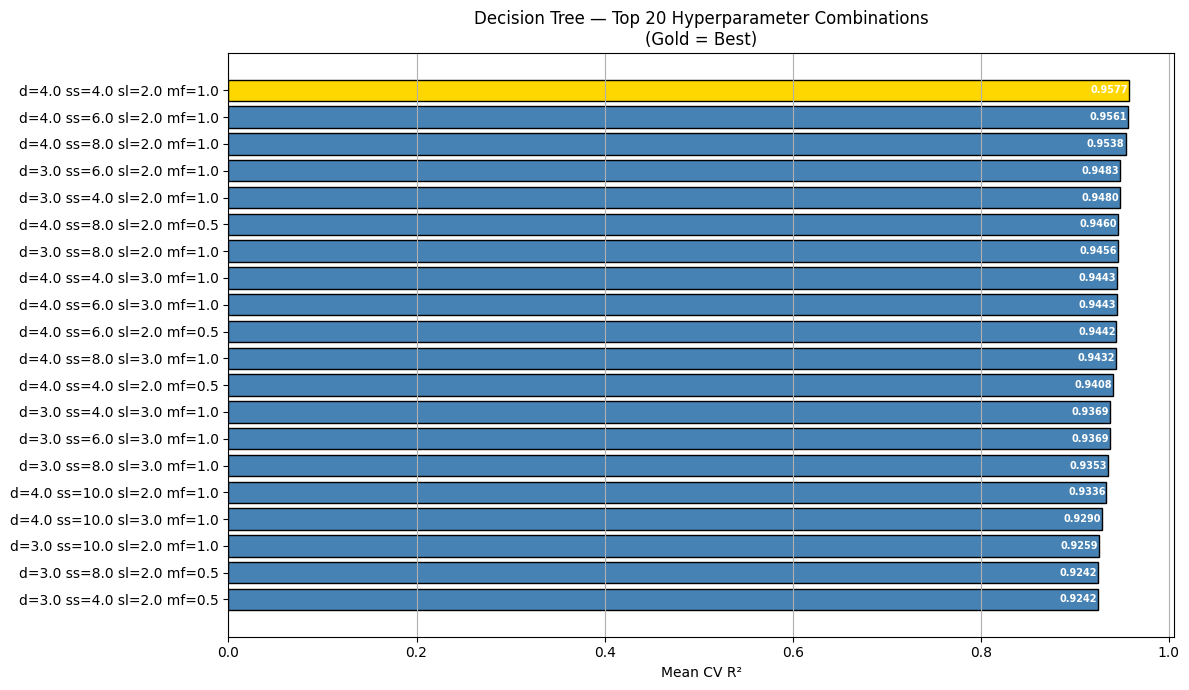

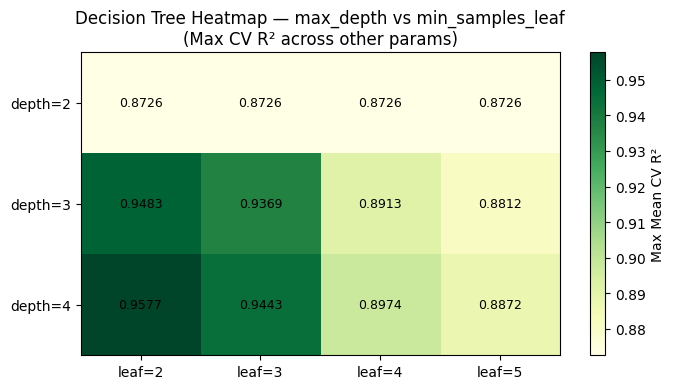

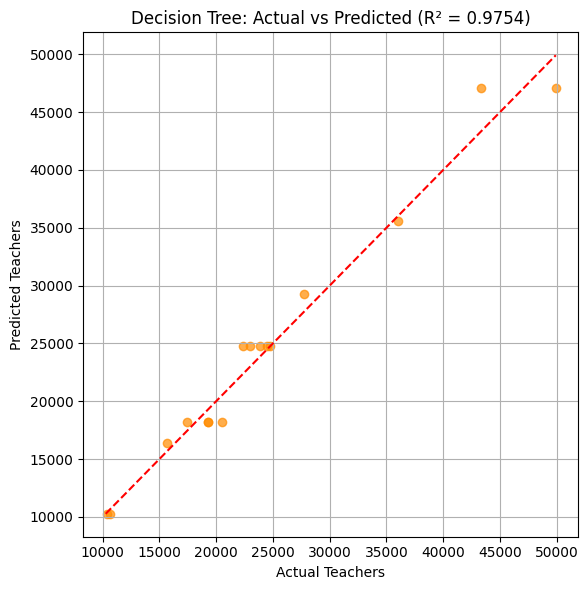

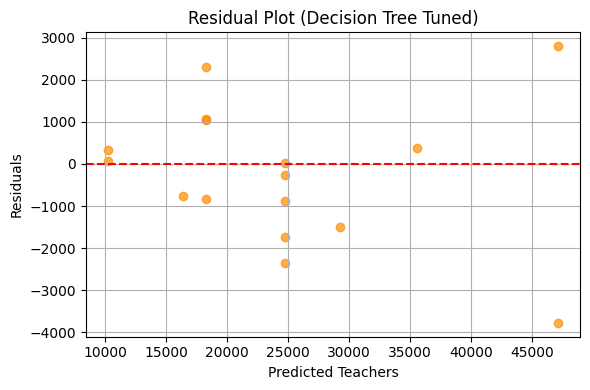

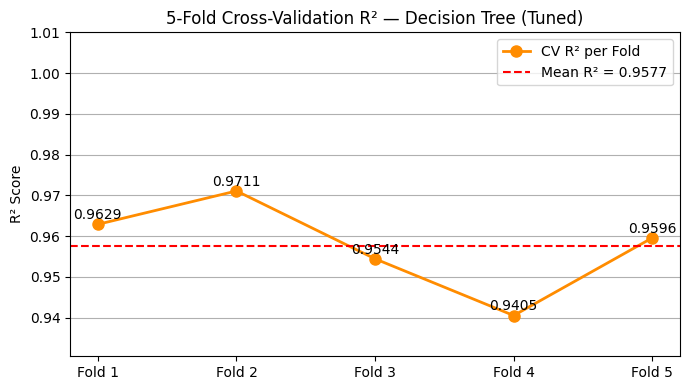

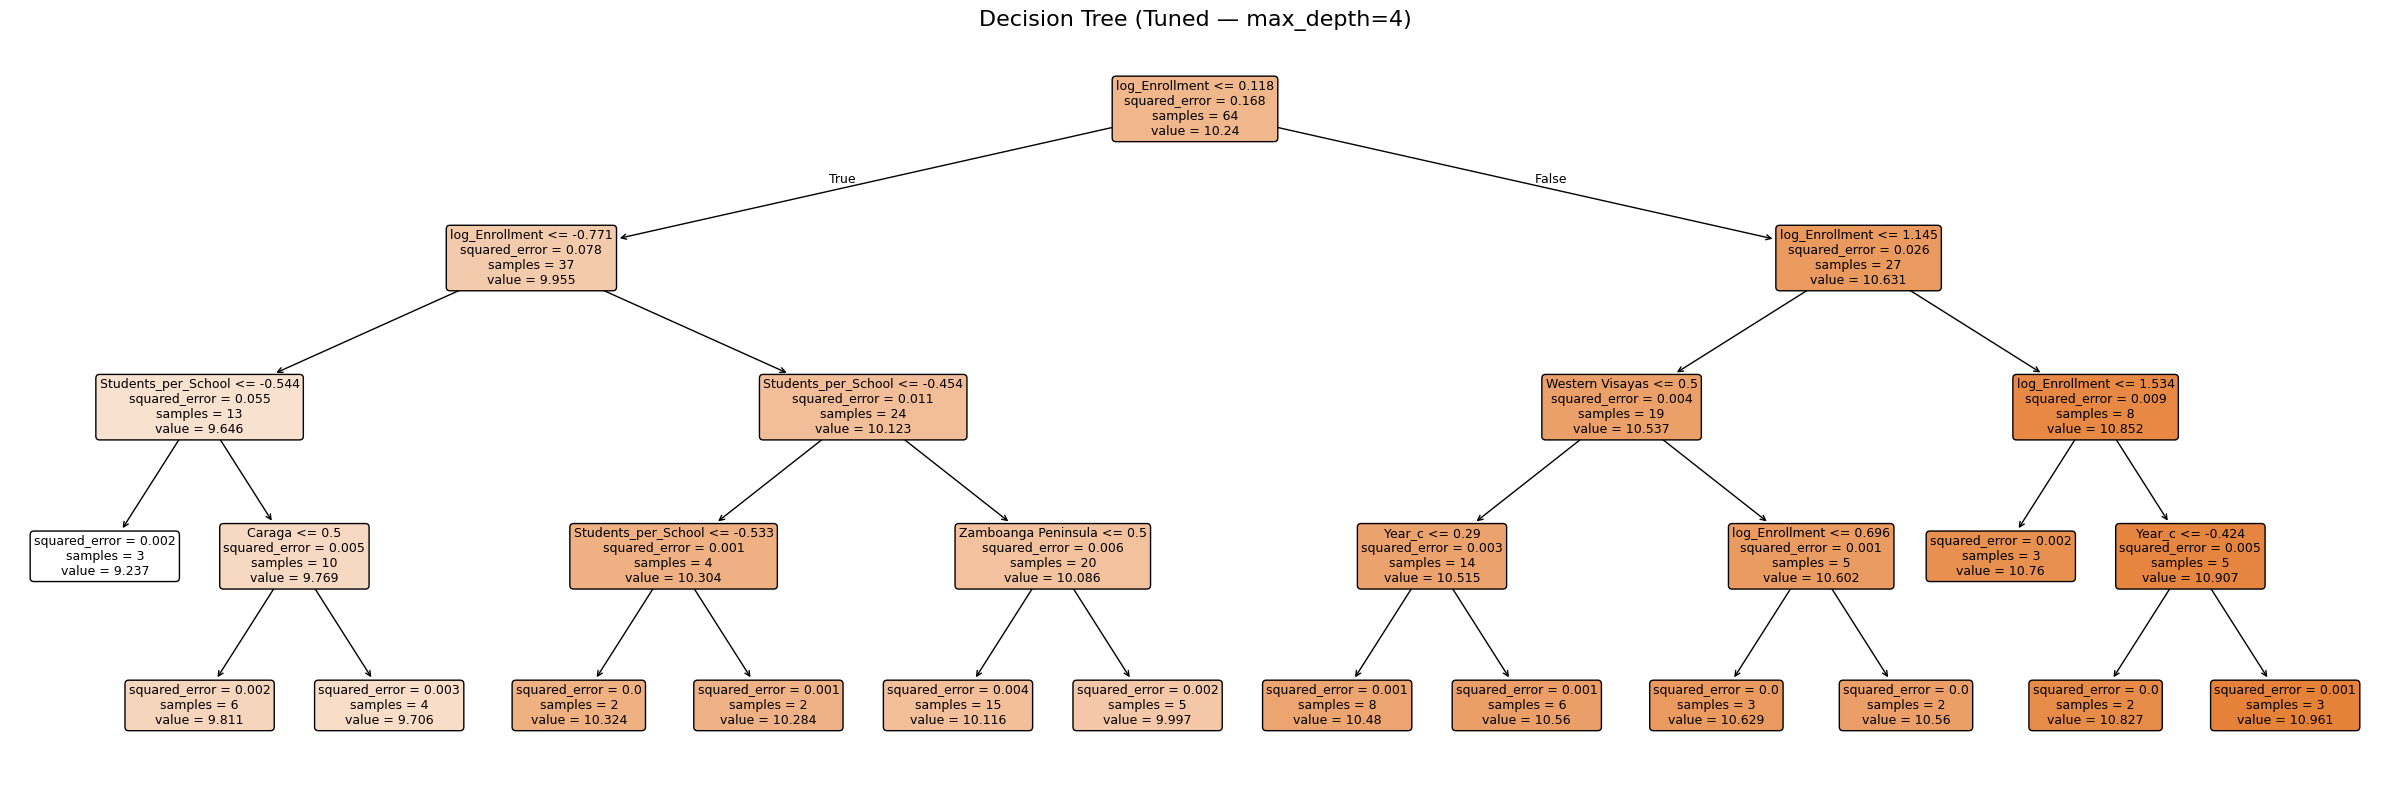

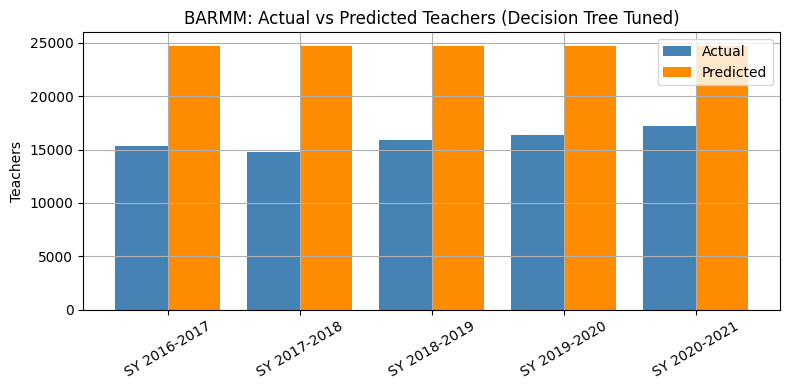


=== BARMM OUT-OF-SAMPLE RESULTS (Decision Tree Tuned) ===
    School_Year  Teachers  Predicted_Teachers  Error_%
0  SY 2016-2017     15361          24741.4723  61.0668
1  SY 2017-2018     14811          24741.4723  67.0480
2  SY 2018-2019     15863          24741.4723  55.9697
3  SY 2019-2020     16348          24741.4723  51.3425
4  SY 2020-2021     17228          24741.4723  43.6120

Average BARMM Error: 55.8%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------
df_model = pd.read_csv('df_model_clean.csv')

# ----------------------------------------------------------
# FEATURES & TARGET — same as MLR
# ----------------------------------------------------------
feature_cols   = ['log_Enrollment', 'Students_per_School', 'Year_c', 'Year_squared']
region_dummies = pd.get_dummies(df_model['Region'], drop_first=True)

X_raw = pd.concat([df_model[feature_cols], region_dummies], axis=1)
y     = df_model['log_Teachers']

num_cols   = feature_cols
dummy_cols = list(region_dummies.columns)

# ----------------------------------------------------------
# TRAIN-TEST SPLIT — same seed as MLR
# ----------------------------------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# SCALING — same as MLR
# ----------------------------------------------------------
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_raw[num_cols])
X_test_num  = scaler.transform(X_test_raw[num_cols])

X_train = np.hstack([X_train_num, X_train_raw[dummy_cols].values])
X_test  = np.hstack([X_test_num,  X_test_raw[dummy_cols].values])

# ----------------------------------------------------------
# GRID SEARCH — find best hyperparameters to prevent overfitting
# ----------------------------------------------------------
param_grid = {
    'max_depth':         [2, 3, 4],
    'min_samples_split': [4, 6, 8, 10],
    'min_samples_leaf':  [2, 3, 4, 5],
    'max_features':      [0.5, 0.7, 1.0]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True   # <-- added so we can log train scores too
)
grid_search.fit(X_train, y_train)

# ----------------------------------------------------------
# LOG ALL HYPERPARAMETER COMBINATIONS
# ----------------------------------------------------------
results_df = pd.DataFrame(grid_search.cv_results_)

# Select and rename the columns we care about
log_cols = {
    'param_max_depth':         'max_depth',
    'param_min_samples_split': 'min_samples_split',
    'param_min_samples_leaf':  'min_samples_leaf',
    'param_max_features':      'max_features',
    'mean_train_score':        'Mean Train R²',
    'mean_test_score':         'Mean CV R²',
    'std_test_score':          'Std CV R²',
    'rank_test_score':         'Rank',
}
results_log = results_df[list(log_cols.keys())].rename(columns=log_cols)
results_log = results_log.sort_values('Rank').reset_index(drop=True)
results_log['Train-CV Gap'] = (results_log['Mean Train R²'] - results_log['Mean CV R²']).abs().round(4)

print("=" * 90)
print("  DECISION TREE — ALL HYPERPARAMETER COMBINATIONS (sorted by CV R², best first)")
print("=" * 90)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(results_log.to_string(index=False))
print(f"\nTotal combinations tested: {len(results_log)}")

# ----------------------------------------------------------
# BEST PARAMETERS SUMMARY
# ----------------------------------------------------------
best_params = grid_search.best_params_
print("\n" + "=" * 50)
print("  BEST PARAMETERS FOUND")
print("=" * 50)
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  Best Mean CV R²: {grid_search.best_score_:.4f}")

# ----------------------------------------------------------
# FINAL MODEL with best parameters
# ----------------------------------------------------------
dt = DecisionTreeRegressor(random_state=42, **best_params)
dt.fit(X_train, y_train)

# ----------------------------------------------------------
# PREDICTIONS — back-transform with np.exp()
# ----------------------------------------------------------
y_pred_train_log = dt.predict(X_train)
y_pred_test_log  = dt.predict(X_test)

y_train_real = np.exp(y_train)
y_test_real  = np.exp(y_test)

y_pred_train = np.exp(y_pred_train_log)
y_pred_test  = np.exp(y_pred_test_log)

# ----------------------------------------------------------
# CROSS-VALIDATION with best parameters
# ----------------------------------------------------------
cv_scores = cross_val_score(
    DecisionTreeRegressor(random_state=42, **best_params),
    X_train, y_train, cv=5, scoring='r2'
)

# ----------------------------------------------------------
# EVALUATION METRICS
# ----------------------------------------------------------
r2_train = r2_score(y_train_real, y_pred_train)
r2_test  = r2_score(y_test_real,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
mae      = mean_absolute_error(y_test_real, y_pred_test)

print("\n" + "=" * 50)
print("  DECISION TREE RESULTS (Tuned)")
print("=" * 50)
print(f"R² Train      : {r2_train:.4f}")
print(f"R² Test       : {r2_test:.4f}")
print(f"Train-Test Gap: {abs(r2_train - r2_test):.4f}  (lower is better)")
print(f"RMSE          : {rmse:,.2f}")
print(f"MAE           : {mae:,.2f}")
print(f"CV R² Scores  : {np.round(cv_scores, 4)}")
print(f"Mean CV R²    : {cv_scores.mean():.4f}")
print(f"Std CV R²     : {cv_scores.std():.4f}")

# ----------------------------------------------------------
# VISUALIZATION A — Top 20 Combinations by CV R²
# ----------------------------------------------------------
top20 = results_log.head(20).copy()
labels = [
    f"d={row['max_depth']} ss={row['min_samples_split']} sl={row['min_samples_leaf']} mf={row['max_features']}"
    for _, row in top20.iterrows()
]

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(top20))]
bars = ax.barh(labels[::-1], top20['Mean CV R²'].values[::-1], color=colors[::-1], edgecolor='black')
for bar in bars:
    ax.text(bar.get_width() - 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', ha='right', fontsize=7, color='white', fontweight='bold')
ax.set_xlabel('Mean CV R²')
ax.set_title('Decision Tree — Top 20 Hyperparameter Combinations\n(Gold = Best)')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION B — Heatmap: max_depth vs min_samples_leaf (mean CV R²)
# ----------------------------------------------------------
pivot = results_df.pivot_table(
    index='param_max_depth',
    columns='param_min_samples_leaf',
    values='mean_test_score',
    aggfunc='max'
)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'leaf={v}' for v in pivot.columns])
ax.set_yticklabels([f'depth={v}' for v in pivot.index])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:.4f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Max Mean CV R²')
ax.set_title('Decision Tree Heatmap — max_depth vs min_samples_leaf\n(Max CV R² across other params)')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION C — Actual vs Predicted
# ----------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test_real, y_pred_test, alpha=0.7, color='darkorange')
mn = min(y_test_real.min(), y_pred_test.min())
mx = max(y_test_real.max(), y_pred_test.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Actual Teachers")
plt.ylabel("Predicted Teachers")
plt.title(f"Decision Tree: Actual vs Predicted (R² = {r2_test:.4f})")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION D — Residual Plot
# ----------------------------------------------------------
residuals = y_test_real - y_pred_test

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_test, residuals, alpha=0.7, color='darkorange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Teachers")
plt.ylabel("Residuals")
plt.title("Residual Plot (Decision Tree Tuned)")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION E — CV Scores Line Chart
# ----------------------------------------------------------
plt.figure(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
plt.plot(folds, cv_scores, marker='o', color='darkorange',
         linewidth=2, markersize=8, label='CV R² per Fold')
for i, score in enumerate(cv_scores):
    plt.text(i, score + 0.0005, f'{score:.4f}', ha='center', va='bottom', fontsize=10)
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean R² = {cv_scores.mean():.4f}')
plt.ylim(cv_scores.min() - 0.01, 1.01)
plt.ylabel("R² Score")
plt.title("5-Fold Cross-Validation R² — Decision Tree (Tuned)")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION F — Decision Tree Plot
# ----------------------------------------------------------
feature_names = num_cols + dummy_cols

plt.figure(figsize=(24, 8))
plot_tree(
    dt,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,
    precision=3
)
plt.title(f"Decision Tree (Tuned — max_depth={best_params['max_depth']})", fontsize=16)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# BARMM OUT-OF-SAMPLE PREDICTION
# ----------------------------------------------------------
df_barmm = pd.read_csv('df_barmm_clean.csv')

X_barmm_num = scaler.transform(df_barmm[num_cols])
barmm_dummies = pd.DataFrame(
    np.zeros((len(df_barmm), len(dummy_cols))), columns=dummy_cols
)
X_barmm = np.hstack([X_barmm_num, barmm_dummies.values])

barmm_pred_log = dt.predict(X_barmm)
df_barmm['Predicted_Teachers'] = np.exp(barmm_pred_log)

plt.figure(figsize=(8, 4))
x = np.arange(len(df_barmm))
plt.bar(x - 0.2, df_barmm['Teachers'],           0.4, label='Actual',    color='steelblue')
plt.bar(x + 0.2, df_barmm['Predicted_Teachers'], 0.4, label='Predicted', color='darkorange')
plt.xticks(x, df_barmm['School_Year'], rotation=30)
plt.title("BARMM: Actual vs Predicted Teachers (Decision Tree Tuned)")
plt.ylabel("Teachers")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

df_barmm['Error']   = df_barmm['Teachers'] - df_barmm['Predicted_Teachers']
df_barmm['Error_%'] = (abs(df_barmm['Error']) / df_barmm['Teachers']) * 100

print("\n=== BARMM OUT-OF-SAMPLE RESULTS (Decision Tree Tuned) ===")
print(df_barmm[['School_Year', 'Teachers', 'Predicted_Teachers', 'Error_%']])
print(f"\nAverage BARMM Error: {df_barmm['Error_%'].mean():.1f}%")

  RANDOM FOREST — ALL HYPERPARAMETER COMBINATIONS (sorted by CV R², best first)
 n_estimators max_depth  min_samples_split  min_samples_leaf max_features  Mean Train R²  Mean CV R²  Std CV R²  Rank  Train-CV Gap
          200      None                  2                 1       1.0000         0.9960      0.9764     0.0062     1        0.0196
          100      None                  2                 1       1.0000         0.9959      0.9762     0.0064     2        0.0197
          300      None                  2                 1       1.0000         0.9956      0.9751     0.0069     3        0.0204
          200         5                  2                 1       1.0000         0.9948      0.9740     0.0068     4        0.0208
          200      None                  4                 1       1.0000         0.9927      0.9735     0.0080     5        0.0192
          100         5                  2                 1       1.0000         0.9947      0.9735     0.0069     6        0.0

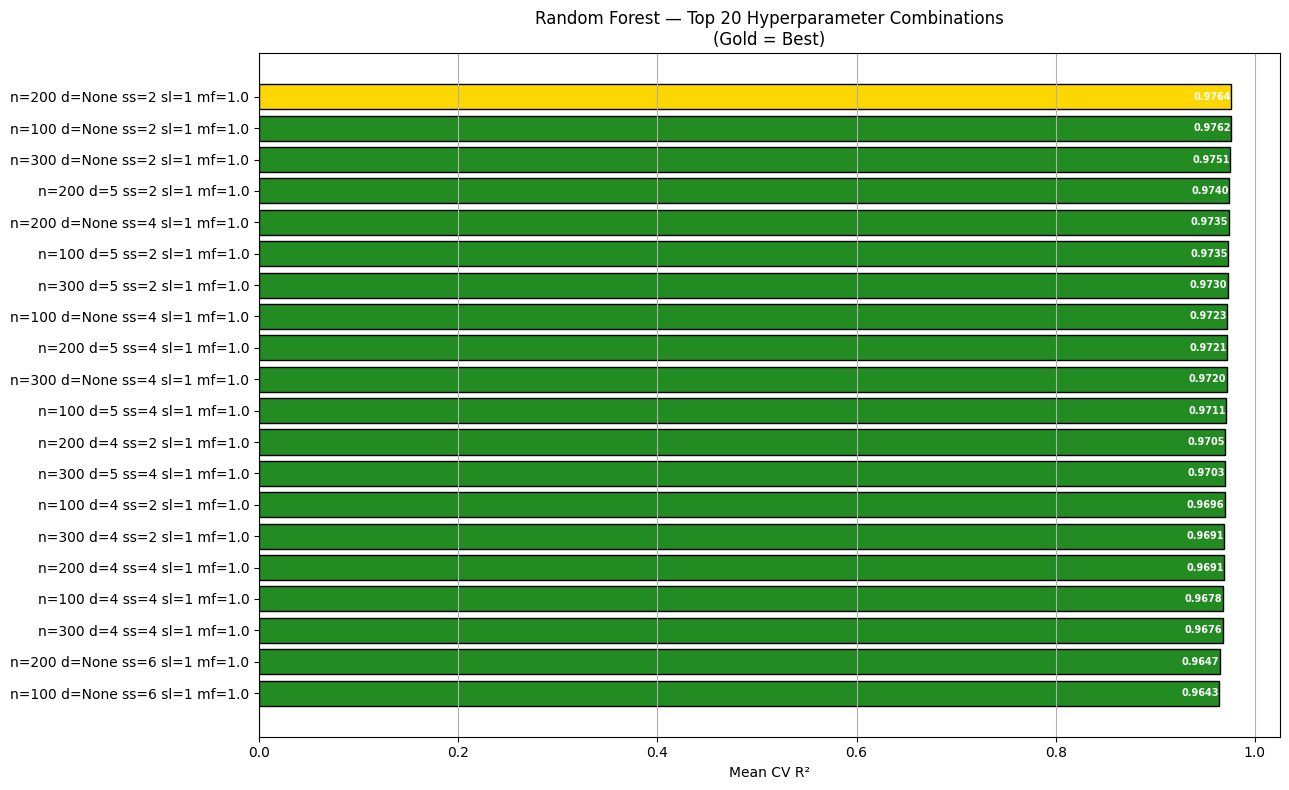

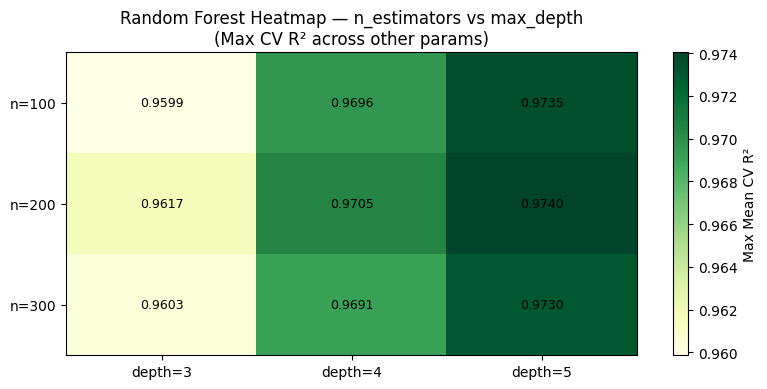

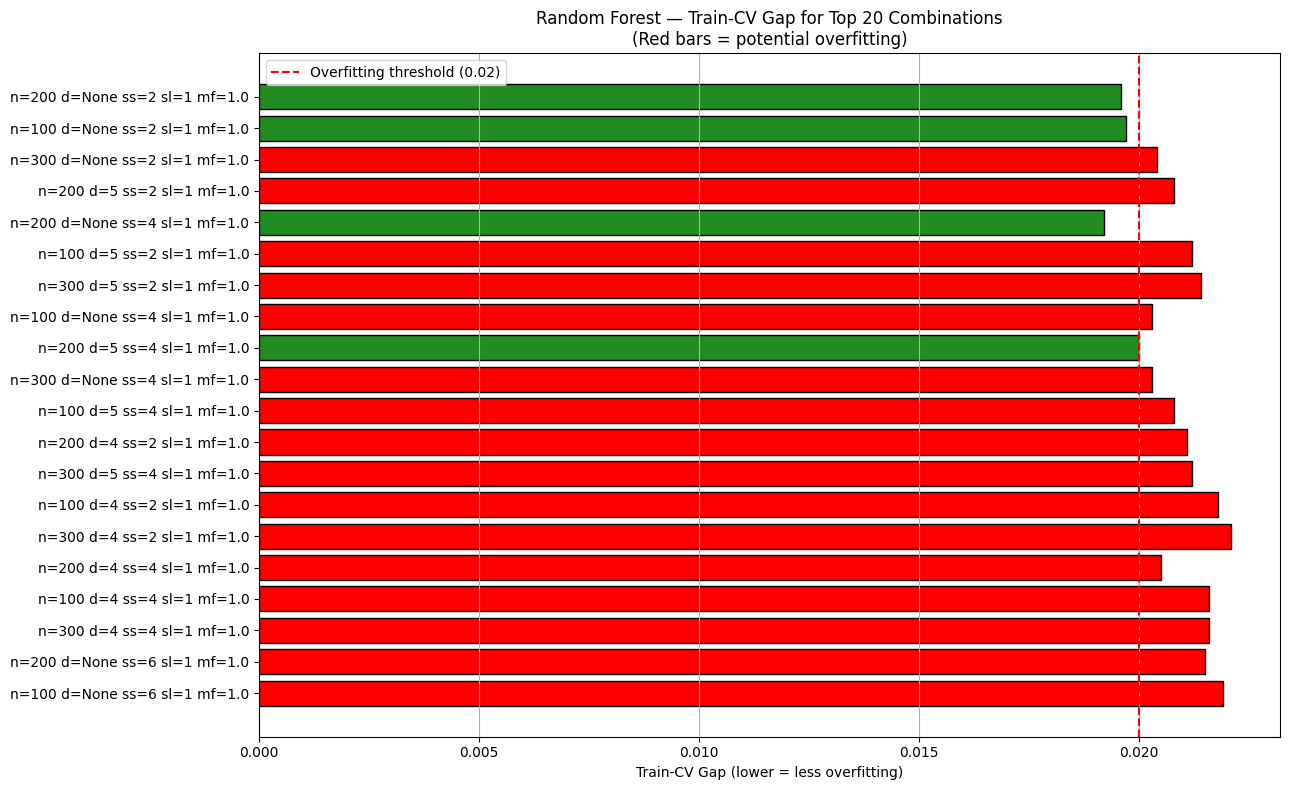

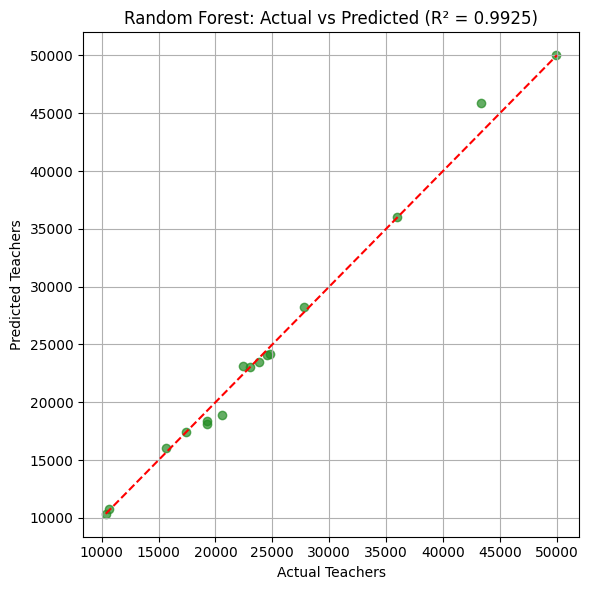

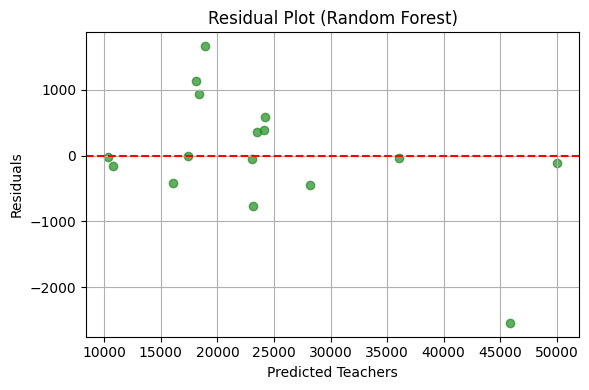

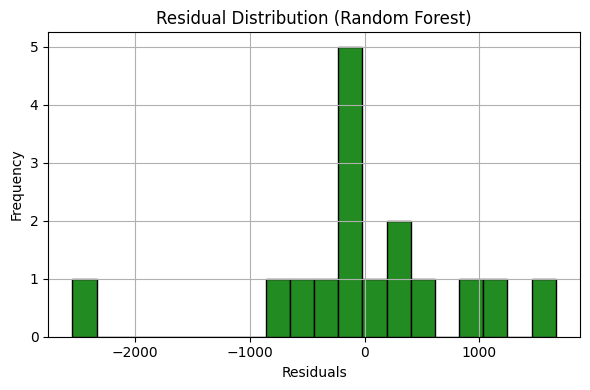

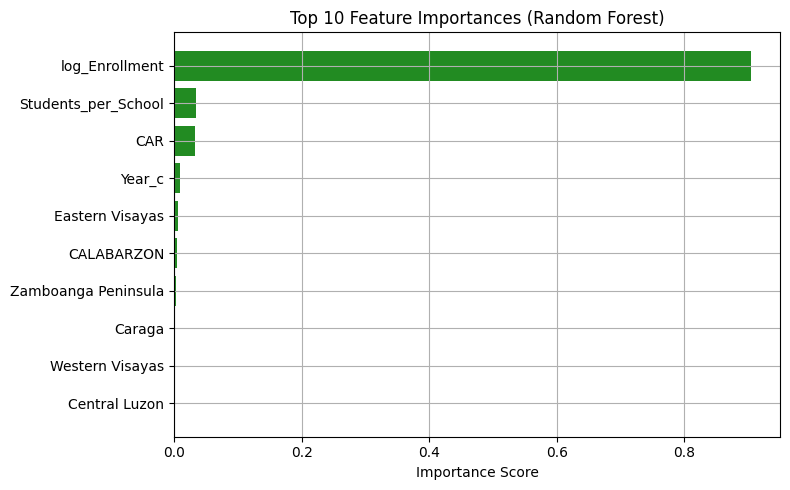


================ TOP FEATURE IMPORTANCES ================
            Feature  Importance
     log_Enrollment      0.9046
Students_per_School      0.0341
                CAR      0.0324
             Year_c      0.0095
    Eastern Visayas      0.0063
         CALABARZON      0.0039
Zamboanga Peninsula      0.0027
             Caraga      0.0019
    Western Visayas      0.0015
      Central Luzon      0.0010


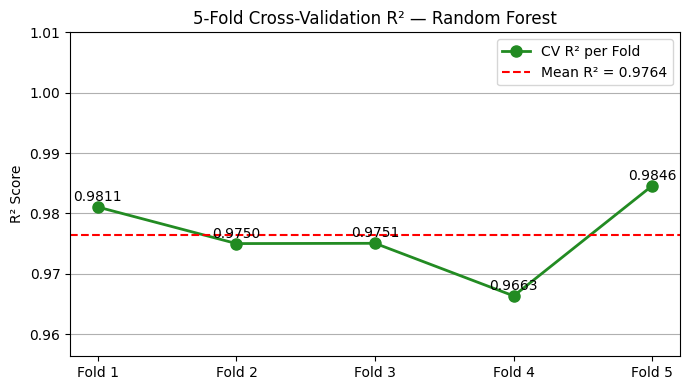

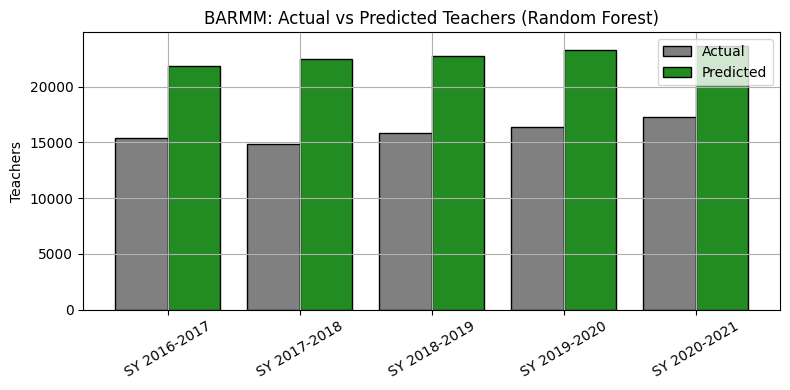


=== BARMM OUT-OF-SAMPLE RESULTS (Random Forest) ===
    School_Year  Teachers  Predicted_Teachers  Error_%
0  SY 2016-2017     15361          21868.9937  42.3670
1  SY 2017-2018     14811          22463.4162  51.6671
2  SY 2018-2019     15863          22753.7492  43.4391
3  SY 2019-2020     16348          23287.8912  42.4510
4  SY 2020-2021     17228          23670.3734  37.3948

Average BARMM Error: 43.5%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------
df_model = pd.read_csv('df_model_clean.csv')
df_barmm = pd.read_csv('df_barmm_clean.csv')

# ----------------------------------------------------------
# FEATURES & TARGET — same as MLR and Decision Tree
# ----------------------------------------------------------
feature_cols   = ['log_Enrollment', 'Students_per_School', 'Year_c', 'Year_squared']
region_dummies = pd.get_dummies(df_model['Region'], drop_first=True)

X_raw = pd.concat([df_model[feature_cols], region_dummies], axis=1)
y     = df_model['log_Teachers']

num_cols   = feature_cols
dummy_cols = list(region_dummies.columns)

# ----------------------------------------------------------
# TRAIN-TEST SPLIT — same seed as MLR and Decision Tree
# ----------------------------------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# SCALING — same as MLR and Decision Tree
# ----------------------------------------------------------
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_raw[num_cols])
X_test_num  = scaler.transform(X_test_raw[num_cols])

X_train = np.hstack([X_train_num, X_train_raw[dummy_cols].values])
X_test  = np.hstack([X_test_num,  X_test_raw[dummy_cols].values])

# ----------------------------------------------------------
# GRID SEARCH — find best hyperparameters
# ----------------------------------------------------------
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 4, 5, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf':  [1, 2, 3],
    'max_features':      ['sqrt', 'log2', 1.0]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True   # <-- added so we can log train scores too
)
grid_search.fit(X_train, y_train)

# ----------------------------------------------------------
# LOG ALL HYPERPARAMETER COMBINATIONS
# ----------------------------------------------------------
results_df = pd.DataFrame(grid_search.cv_results_)

log_cols = {
    'param_n_estimators':      'n_estimators',
    'param_max_depth':         'max_depth',
    'param_min_samples_split': 'min_samples_split',
    'param_min_samples_leaf':  'min_samples_leaf',
    'param_max_features':      'max_features',
    'mean_train_score':        'Mean Train R²',
    'mean_test_score':         'Mean CV R²',
    'std_test_score':          'Std CV R²',
    'rank_test_score':         'Rank',
}
results_log = results_df[list(log_cols.keys())].rename(columns=log_cols)
results_log = results_log.sort_values('Rank').reset_index(drop=True)
results_log['Train-CV Gap'] = (results_log['Mean Train R²'] - results_log['Mean CV R²']).abs().round(4)

print("=" * 105)
print("  RANDOM FOREST — ALL HYPERPARAMETER COMBINATIONS (sorted by CV R², best first)")
print("=" * 105)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(results_log.to_string(index=False))
print(f"\nTotal combinations tested: {len(results_log)}")

# ----------------------------------------------------------
# BEST PARAMETERS SUMMARY
# ----------------------------------------------------------
best_params = grid_search.best_params_
print("\n" + "=" * 50)
print("  BEST PARAMETERS FOUND")
print("=" * 50)
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  Best Mean CV R²: {grid_search.best_score_:.4f}")

# ----------------------------------------------------------
# FINAL MODEL with best parameters
# ----------------------------------------------------------
rf = RandomForestRegressor(random_state=42, **best_params)
rf.fit(X_train, y_train)

# ----------------------------------------------------------
# PREDICTIONS — back-transform with np.exp()
# ----------------------------------------------------------
y_pred_train_log = rf.predict(X_train)
y_pred_test_log  = rf.predict(X_test)

y_train_real = np.exp(y_train)
y_test_real  = np.exp(y_test)

y_pred_train = np.exp(y_pred_train_log)
y_pred_test  = np.exp(y_pred_test_log)

# ----------------------------------------------------------
# CROSS-VALIDATION with best parameters
# ----------------------------------------------------------
cv_scores = cross_val_score(
    RandomForestRegressor(random_state=42, **best_params),
    X_train, y_train, cv=5, scoring='r2'
)

# ----------------------------------------------------------
# EVALUATION METRICS
# ----------------------------------------------------------
r2_train = r2_score(y_train_real, y_pred_train)
r2_test  = r2_score(y_test_real,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test_real, y_pred_test))
mae      = mean_absolute_error(y_test_real, y_pred_test)

print("\n" + "=" * 50)
print("  RANDOM FOREST RESULTS (Tuned)")
print("=" * 50)
print(f"R² Train      : {r2_train:.4f}")
print(f"R² Test       : {r2_test:.4f}")
print(f"Train-Test Gap: {abs(r2_train - r2_test):.4f}  (lower is better)")
print(f"RMSE          : {rmse:,.2f}")
print(f"MAE           : {mae:,.2f}")
print(f"CV R² Scores  : {np.round(cv_scores, 4)}")
print(f"Mean CV R²    : {cv_scores.mean():.4f}")
print(f"Std CV R²     : {cv_scores.std():.4f}")

# ----------------------------------------------------------
# VISUALIZATION A — Top 20 Combinations by CV R²
# ----------------------------------------------------------
top20 = results_log.head(20).copy()
labels = [
    f"n={row['n_estimators']} d={row['max_depth']} ss={row['min_samples_split']} sl={row['min_samples_leaf']} mf={row['max_features']}"
    for _, row in top20.iterrows()
]

fig, ax = plt.subplots(figsize=(13, 8))
colors = ['gold' if i == 0 else 'forestgreen' for i in range(len(top20))]
bars = ax.barh(labels[::-1], top20['Mean CV R²'].values[::-1], color=colors[::-1], edgecolor='black')
for bar in bars:
    ax.text(bar.get_width() - 0.0005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', ha='right', fontsize=7, color='white', fontweight='bold')
ax.set_xlabel('Mean CV R²')
ax.set_title('Random Forest — Top 20 Hyperparameter Combinations\n(Gold = Best)')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION B — Heatmap: n_estimators vs max_depth (mean CV R²)
# ----------------------------------------------------------
pivot = results_df.pivot_table(
    index='param_n_estimators',
    columns='param_max_depth',
    values='mean_test_score',
    aggfunc='max'
)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'depth={v}' for v in pivot.columns])
ax.set_yticklabels([f'n={v}' for v in pivot.index])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:.4f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Max Mean CV R²')
ax.set_title('Random Forest Heatmap — n_estimators vs max_depth\n(Max CV R² across other params)')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION C — Train-CV Gap: Top 20 (overfitting check)
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 8))
gap_colors = ['red' if g > 0.02 else 'forestgreen' for g in top20['Train-CV Gap'].values[::-1]]
ax.barh(labels[::-1], top20['Train-CV Gap'].values[::-1], color=gap_colors, edgecolor='black')
ax.axvline(0.02, color='red', linestyle='--', label='Overfitting threshold (0.02)')
ax.set_xlabel('Train-CV Gap (lower = less overfitting)')
ax.set_title('Random Forest — Train-CV Gap for Top 20 Combinations\n(Red bars = potential overfitting)')
ax.legend()
ax.grid(axis='x')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION D — Actual vs Predicted
# ----------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test_real, y_pred_test, alpha=0.7, color='forestgreen')
mn = min(y_test_real.min(), y_pred_test.min())
mx = max(y_test_real.max(), y_pred_test.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Actual Teachers")
plt.ylabel("Predicted Teachers")
plt.title(f"Random Forest: Actual vs Predicted (R² = {r2_test:.4f})")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION E — Residual Plot
# ----------------------------------------------------------
residuals = y_test_real - y_pred_test

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_test, residuals, alpha=0.7, color='forestgreen')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Teachers")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION F — Residual Distribution
# ----------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, edgecolor='black', color='forestgreen')
plt.title("Residual Distribution (Random Forest)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# VISUALIZATION G — Feature Importance
# ----------------------------------------------------------
feature_names = num_cols + dummy_cols
importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10], color='forestgreen')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.grid()
plt.tight_layout()
plt.show()

print("\n================ TOP FEATURE IMPORTANCES ================")
print(importance_df.head(10).to_string(index=False))

# ----------------------------------------------------------
# VISUALIZATION H — CV Scores Line Chart
# ----------------------------------------------------------
plt.figure(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
plt.plot(folds, cv_scores, marker='o', color='forestgreen',
         linewidth=2, markersize=8, label='CV R² per Fold')
for i, score in enumerate(cv_scores):
    plt.text(i, score + 0.0005, f'{score:.4f}', ha='center', va='bottom', fontsize=10)
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean R² = {cv_scores.mean():.4f}')
plt.ylim(cv_scores.min() - 0.01, 1.01)
plt.ylabel("R² Score")
plt.title("5-Fold Cross-Validation R² — Random Forest")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# BARMM OUT-OF-SAMPLE PREDICTION
# ----------------------------------------------------------
df_barmm = pd.read_csv('df_barmm_clean.csv')

X_barmm_num = scaler.transform(df_barmm[num_cols])
barmm_dummies = pd.DataFrame(
    np.zeros((len(df_barmm), len(dummy_cols))), columns=dummy_cols
)
X_barmm = np.hstack([X_barmm_num, barmm_dummies.values])

barmm_pred_log = rf.predict(X_barmm)
df_barmm['Predicted_Teachers'] = np.exp(barmm_pred_log)

plt.figure(figsize=(8, 4))
x = np.arange(len(df_barmm))
plt.bar(x - 0.2, df_barmm['Teachers'],           0.4, label='Actual',    color='gray',        edgecolor='black')
plt.bar(x + 0.2, df_barmm['Predicted_Teachers'], 0.4, label='Predicted', color='forestgreen', edgecolor='black')
plt.xticks(x, df_barmm['School_Year'], rotation=30)
plt.title("BARMM: Actual vs Predicted Teachers (Random Forest)")
plt.ylabel("Teachers")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

df_barmm['Error']   = df_barmm['Teachers'] - df_barmm['Predicted_Teachers']
df_barmm['Error_%'] = (abs(df_barmm['Error']) / df_barmm['Teachers']) * 100

print("\n=== BARMM OUT-OF-SAMPLE RESULTS (Random Forest) ===")
print(df_barmm[['School_Year', 'Teachers', 'Predicted_Teachers', 'Error_%']])
print(f"\nAverage BARMM Error: {df_barmm['Error_%'].mean():.1f}%")